In [14]:
import requests

# Paste the link address of the "Data Dictionary" from the Census website
dictionary_url = "https://data.nber.org/morg/annual/desc/morg09/desc.txt"

# Fetch the content
response = requests.get(dictionary_url)

# Check if the fetch was successful
if response.status_code == 200:
    print("File is plain text:\n")
    # print the 51 lines after the line that contains "dind02:"
    # these lines are a integer code, a space, then the industry name. The codes are consecutive
    # create a dictionary mapping code to industry name for codes 1 - 50, then print the dictionary
    lines = response.text.splitlines()
    industry_dict = {}
    for i, line in enumerate(lines):
        if "dind02:" in line:
            for j in range(1, 51):
                if i + j < len(lines) and lines[i + j].strip():
                    code, name = lines[i + j].strip().partition(' ')[::2]  # split on first space
                    industry_dict[j] = name.strip()
            break
    print(industry_dict)
else:    print(f"Failed to fetch the file. Status code: {response.status_code}")

File is plain text:

{1: 'Agriculture', 2: 'Forestry, logging, fishing, hunting, and trapping', 3: 'Mining', 4: 'Construction', 5: 'Nonmetallic mineral products', 6: 'Primary metals and fabricated metal products', 7: 'Machinery manufacturing', 8: 'Computer and electronic products', 9: 'Electrical equipment, appliance manufacturing', 10: 'Transportation equipment manufacturing', 11: 'Wood products', 12: 'Furniture and fixtures manufacturing', 13: 'Miscellaneous and not specified manufacturing', 14: 'Food manufacturing', 15: 'Beverage and tobacco products', 16: 'Textile, apparel, and leather manufacturing', 17: 'Paper and printing', 18: 'Petroleum and coal products', 19: 'Chemical manufacturing', 20: 'Plastics and rubber products', 21: 'Wholesale trade', 22: 'Retail trade', 23: 'Transportation and warehousing', 24: 'Utilities', 25: 'Publishing industries (except internet)', 26: 'Motion picture and sound recording industries', 27: 'Broadcasting (except internet)', 28: 'Internet publishing

# Start Env

In [3]:
# LOAD DF

import pandas as pd

file_path = "/common/users/bh567/cs439/zhang_u1.parquet"
#file_path = "/common/users/bh567/cs439/nber_morg_2009_2015.parquet"

print("Loading master dataset...")
df_master = pd.read_parquet(file_path)

print("--- Master Dataset Successfully Loaded! ---")
print(f"Total Rows: {len(df_master)}")

Loading master dataset...
--- Master Dataset Successfully Loaded! ---
Total Rows: 876214


# Data Acquisition

## Raw Basic Monthly CPS

### Fetch

In [ ]:
%%script echo skipping

!apt-get update -qq
!apt-get install -y -qq aria2

In [ ]:
%%script echo skipping

# DOWNLOAD RAW FILES - COMPLETED

import os
import subprocess

# Define the target directory
target_dir = "/content/drive/MyDrive/repo/data"
os.makedirs(target_dir, exist_ok=True)

# Define the time range and months
years = range(2009, 2016)
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

print(f"Starting rapid downloads to {target_dir}...")

for year in years:
    year_short = str(year)[2:] # e.g., '09'
    for month in months:
        # Construct the URL and filename
        file_name = f"{month}{year_short}pub.dat.gz"
        url = f"https://www2.census.gov/programs-surveys/cps/datasets/{year}/basic/{file_name}"

        print(f"Processing {file_name}...", end=" ", flush=True)

        # Build the aria2c command
        # -x 4: Uses 4 connections per server
        # -s 4: Splits the file into 4 concurrent chunks
        # -c: Automatically resumes partial downloads or skips if already complete
        # --console-log-level=error: Keeps the Colab output clean
        command = [
            'aria2c', '-x', '4', '-s', '4', '-c',
            '--console-log-level=error', '--summary-interval=0',
            '-d', target_dir, '-o', file_name, url
        ]

        try:
            # Execute the command
            subprocess.run(command, check=True)
            print("Done. ✅")
        except subprocess.CalledProcessError:
            print("Failed. ❌")

print("\nAll downloads completed!")

In [ ]:
import requests
from IPython.display import display, HTML

# Paste the link address of the "Data Dictionary" from the Census website
dictionary_url = "https://data.nber.org/morg/annual/desc/morg09/desc.txt"

# Fetch the content
response = requests.get(dictionary_url)

# Check if the fetch was successful
if response.status_code == 200:
    # If the file is HTML, render it directly in the Colab output
    if 'html' in response.headers.get('Content-Type', '').lower():
        display(HTML(response.text))
    else:
        # If it's a text file, print the first 2000 characters to inspect the layout
        print("File is plain text:\n" + ("="*40 + "\n") + response.text)

In [ ]:
import re

text = response.text
print(f"Dictionary loaded. Length: {len(text)} characters.")

# UPDATED: Added HRMIS and PRCOW1, removed duplicate wage variables
vars_of_interest = [
    'GESTFIPS', 'HRYEAR4', 'HRMONTH', 'HRMIS', 'PRCOW1',
    'PEAGE', 'PESEX', 'PEEDUCA', 'PTDTRACE', 'PEHSPNON',
    'PEMARITL', 'GTMETSTA', 'PEIO1ICD', 'PEERNLAB', 'PEERNCOV',
    'PRERNHLY', 'PRERNWA', 'PEHRUSL1'
]

pattern = re.compile(r'^([A-Z0-9_]+)\s+\d+\s+.*?\s+(\d+)\s*-\s*(\d+)', re.MULTILINE)

extracted_vars = {}
for match in pattern.finditer(text):
    var_name = match.group(1)
    if var_name in vars_of_interest:
        start = int(match.group(2)) - 1
        end = int(match.group(3))
        extracted_vars[var_name] = (start, end)

col_specs = []
col_names = []

print("\n--- Variables Found ---")
for var in vars_of_interest:
    if var in extracted_vars:
        col_specs.append(extracted_vars[var])
        col_names.append(var)

print(f"Ready to load data with {len(col_names)} columns.")

Dictionary loaded. Length: 148965 characters.

--- Variables Found ---
Ready to load data with 18 columns.


### Filter

In [ ]:
import pandas as pd
import os

# 1. Deduplicate the variables list while preserving the order
unique_vars = []
for v in vars_of_interest:
    if v not in unique_vars and v in extracted_vars:
        unique_vars.append(v)

# 2. Rebuild the specs and names without duplicates
col_specs = [extracted_vars[v] for v in unique_vars]
col_names = unique_vars

all_data = []
data_dir = "/content/drive/MyDrive/repo/data"
files = sorted([f for f in os.listdir(data_dir) if f.endswith('.dat.gz')])

print(f"Processing {len(files)} files with CORRECT Private Sector codes...")

for f in files:
    file_path = os.path.join(data_dir, f)
    df_temp = pd.read_fwf(file_path, colspecs=col_specs, names=col_names, compression='gzip')

    # FILTER 1: Outgoing Rotation Groups (MORG) only
    df_temp = df_temp[df_temp['HRMIS'].isin([4, 8])]

    # FILTER 2: Private, For-Profit Workers
    df_temp = df_temp[df_temp['PRCOW1'] == 4]

    # FILTER 3: Employed only (PEERNLAB is asked only of employed workers)
    # If PEERNLAB is -1, they were not asked the union question
    df_temp = df_temp[df_temp['PEERNLAB'] > 0]

    all_data.append(df_temp)

# Concatenate into the master dataframe
df_master = pd.concat(all_data, ignore_index=True)

# Save over the old Parquet file
df_master.to_parquet("/content/drive/MyDrive/repo/cps_morg_2009_2015.parquet")

print("\n--- NEW Master Dataset Created ---")
print(f"Total Rows: {len(df_master)} (Should be very close to Zhang's 876,214)")

Processing 84 files with CORRECT Private Sector codes...

--- NEW Master Dataset Created ---
Total Rows: 969650 (Should be very close to Zhang's 876,214)


## NBER MORG

In [ ]:
%%script echo skipping

!apt-get update -qq
!apt-get install -y -qq aria2

In [ ]:
%%bash
# Create a dedicated directory for the raw files to keep your repo clean
mkdir -p raw_dta_files
cd raw_dta_files

# Loop through years 09 to 15
for year in {09..15}; do
  echo ">>> Fetching morg${year}.dta..."
  # -x 16 and -s 16 split the download into 16 concurrent connections for max speed
  aria2c -x 16 -s 16 "https://data.nber.org/morg/annual/morg${year}.dta"
done

echo "--- All NBER MORG files downloaded successfully! ---"

In [ ]:
import pandas as pd
import os

# Set paths (assuming your current working directory is /content/drive/MyDrive/repo)
dta_dir = "raw_dta_files"
output_path = "nber_morg_2009_2015.parquet"

# Optional: If your Colab session crashes from running out of RAM, uncomment
# the zhang_cols line and add `columns=zhang_cols` to the read_stata() function.
# zhang_cols = ['earnwke', 'uhourse', 'unionmme', 'unioncov', 'age', 'sex', 'race', 'stfips', 'ind02', 'weight']

all_data = []

print("Stitching NBER MORG .dta files together...")

for year in range(9, 16):
    file_name = f"morg{year:02d}.dta"
    file_path = os.path.join(dta_dir, file_name)

    if os.path.exists(file_path):
        print(f"Loading {file_name}...")
        try:
            # Read the STATA file, keeping variables as numeric codes rather than string categories
            df_year = pd.read_stata(file_path, convert_categoricals=False)

            # Explicitly label the year for your panel data / fixed effects
            df_year['year'] = 2000 + year

            all_data.append(df_year)
        except Exception as e:
            print(f"Error loading {file_name}: {e}")
    else:
        print(f"Warning: {file_name} not found in {dta_dir}!")

# Concatenate all years into the master dataframe
if all_data:
    master_df = pd.concat(all_data, ignore_index=True)
    print(f"\n--- Master DataFrame Created! ---")
    print(f"Total Rows: {len(master_df)}")

    # Save to Parquet
    master_df.to_parquet(output_path)
    print(f"Saved successfully to: {output_path}")
else:
    print("No data was loaded. Please check your file paths.")

Stitching NBER MORG .dta files together...
Loading morg09.dta...
Loading morg10.dta...
Loading morg11.dta...
Loading morg12.dta...
Loading morg13.dta...
Loading morg14.dta...
Loading morg15.dta...

--- Master DataFrame Created! ---
Total Rows: 2224425
Saved successfully to: nber_morg_2009_2015.parquet


# Variable Construction

## Raw Basic Monthly CPS

In [ ]:
import numpy as np

# Use the full master data
df = df_master.copy()

# 1. Create Treatment Indicator (RTW)
def is_rtw(row):
    if row['GESTFIPS'] == 18 and (row['HRYEAR4'] > 2012 or (row['HRYEAR4'] == 2012 and row['HRMONTH'] >= 3)): return 1
    if row['GESTFIPS'] == 26 and (row['HRYEAR4'] > 2013 or (row['HRYEAR4'] == 2013 and row['HRMONTH'] >= 3)): return 1
    return 0

df['rtw'] = df.apply(is_rtw, axis=1)

# 2. Union Indicators
df['union'] = (df['PEERNLAB'] == 1).astype(int)
df['union_cov'] = (df['PEERNCOV'] == 1).astype(int)

# 3. Demographics and Groupings
df['group'] = df['GESTFIPS'].apply(lambda fips: 'Indiana' if fips == 18 else ('Michigan' if fips == 26 else 'Control States'))
df['male'] = (df['PESEX'] == 1).astype(int)
df['white'] = (df['PTDTRACE'] == 1).astype(int)
df['age_sq'] = df['PEAGE'] ** 2
df['time_fe'] = df['HRYEAR4'].astype(str) + "_" + df['HRMONTH'].astype(str)

# 4. CREATE WAGE DATASET (Subsample)
# Calculate hourly wage
df['hourly_wage'] = np.where(df['PRERNHLY'] > 0, df['PRERNHLY'] / 100, df['PRERNWA'] / df['PEHRUSL1'])

# Create a strict subset for wages (must be strictly positive to take log)
df_wage = df[df['hourly_wage'] > 0].copy()

# Apply the 1% Trim on the wage subset ONLY
lower_bound = df_wage['hourly_wage'].quantile(0.01)
upper_bound = df_wage['hourly_wage'].quantile(0.99)
df_wage = df_wage[(df_wage['hourly_wage'] >= lower_bound) & (df_wage['hourly_wage'] <= upper_bound)]
df_wage['logwage'] = np.log(df_wage['hourly_wage'])

print(f"Unionization Sample Size (Figure 1): {len(df)}")
print(f"Wage Regression Sample Size (Table 2): {len(df_wage)}")

Unionization Sample Size (Figure 1): 969650
Wage Regression Sample Size (Table 2): 928702


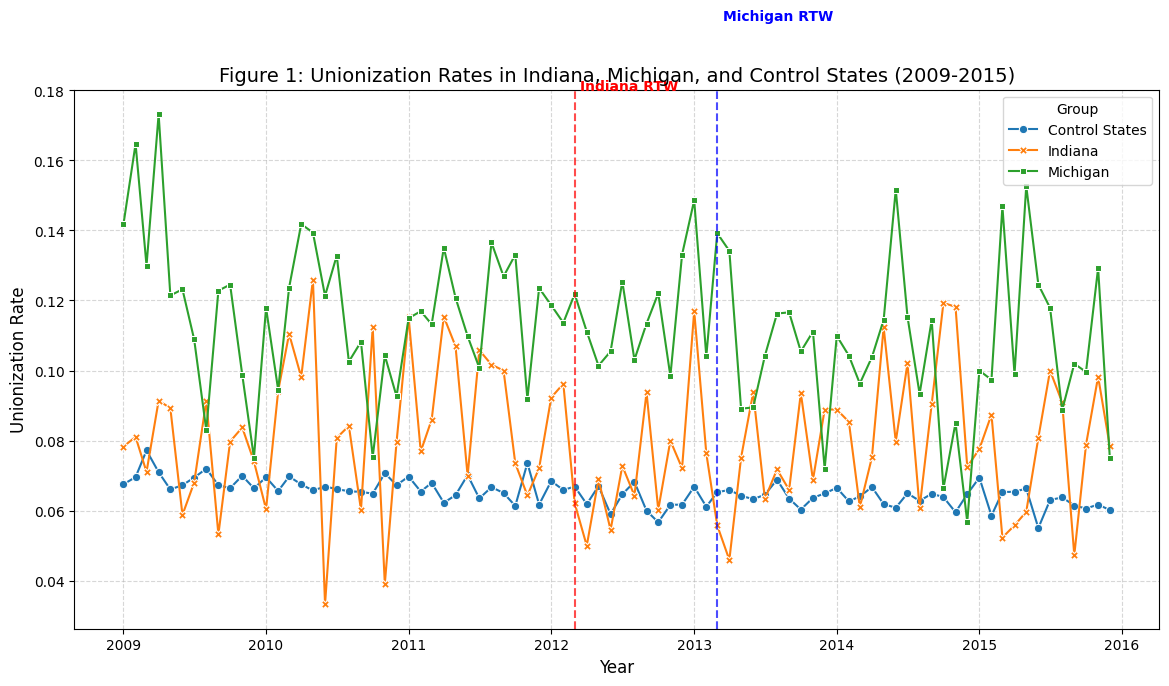

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Categorize states into Indiana, Michigan, and the Control Group
def categorize_state(fips):
    if fips == 18: return 'Indiana'
    if fips == 26: return 'Michigan'
    return 'Control States'

df['group'] = df['GESTFIPS'].apply(categorize_state)

# 2. Create a continuous date column for the x-axis
df['date'] = pd.to_datetime(df['HRYEAR4'].astype(str) + '-' + df['HRMONTH'].astype(str) + '-01')

# 3. Calculate the monthly unionization rate for each group
trend_df = df.groupby(['date', 'group'])['union'].mean().reset_index()

# 4. Visualization
plt.figure(figsize=(14, 7))
sns.lineplot(data=trend_df, x='date', y='union', hue='group', style='group', markers=True, dashes=False)

# Add vertical lines for the policy changes
plt.axvline(pd.Timestamp('2012-03-01'), color='red', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2012-03-15'), 0.18, 'Indiana RTW', color='red', fontweight='bold')

plt.axvline(pd.Timestamp('2013-03-01'), color='blue', linestyle='--', alpha=0.7)
plt.text(pd.Timestamp('2013-03-15'), 0.20, 'Michigan RTW', color='blue', fontweight='bold')

plt.title('Figure 1: Unionization Rates in Indiana, Michigan, and Control States (2009-2015)', fontsize=14)
plt.ylabel('Unionization Rate', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.legend(title='Group')
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.savefig('union_trend.png')

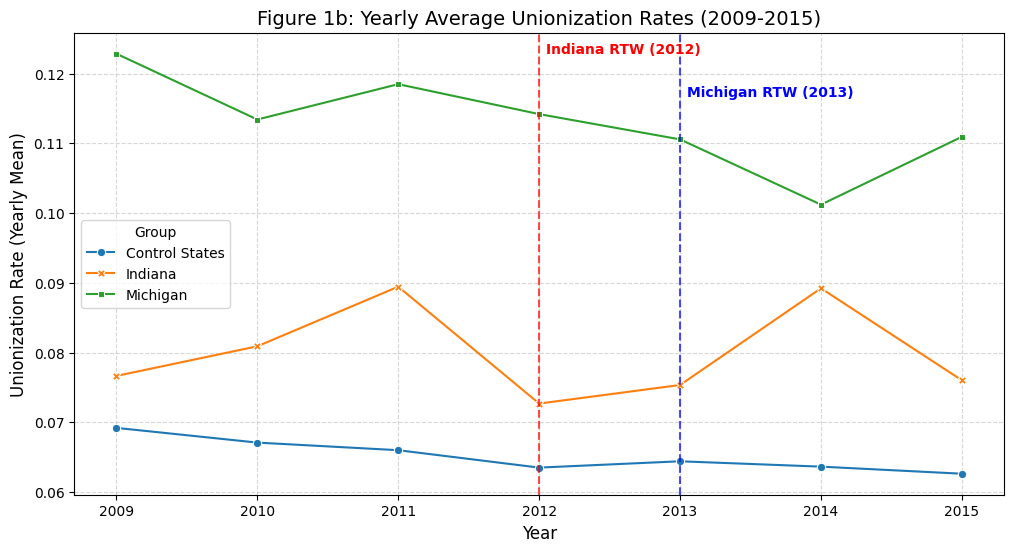

In [ ]:
# 1. Calculate the yearly unionization rate for each group
yearly_trend_df = df.groupby(['HRYEAR4', 'group'])['union'].mean().reset_index()

# 2. Visualization
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trend_df, x='HRYEAR4', y='union', hue='group', style='group', markers=True, dashes=False)

# Add vertical lines for the years of policy changes
# Indiana: 2012, Michigan: 2013
plt.axvline(x=2012, color='red', linestyle='--', alpha=0.7)
plt.text(2012.05, yearly_trend_df['union'].max(), 'Indiana RTW (2012)', color='red', fontweight='bold')

plt.axvline(x=2013, color='blue', linestyle='--', alpha=0.7)
plt.text(2013.05, yearly_trend_df['union'].max() * 0.95, 'Michigan RTW (2013)', color='blue', fontweight='bold')

plt.title('Figure 1b: Yearly Average Unionization Rates (2009-2015)', fontsize=14)
plt.ylabel('Unionization Rate (Yearly Mean)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.xticks(range(2009, 2016)) # Ensure every year is labeled
plt.legend(title='Group')
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig('union_trend_yearly.png')

In [ ]:
import pandas as pd
import numpy as np

# Create a working copy of the master dataset
df_stats = df_master.copy()

# --- FIX 1: Clean Negative CPS Codes ---
df_stats.loc[df_stats['PRERNHLY'] < 0, 'PRERNHLY'] = np.nan
df_stats.loc[df_stats['PRERNWA'] < 0, 'PRERNWA'] = np.nan
df_stats.loc[df_stats['PEHRUSL1'] < 0, 'PEHRUSL1'] = np.nan

# ---------------------------------------------------------
# 1. RTW Variables
# ---------------------------------------------------------
rtw_fips = [1, 4, 5, 12, 13, 16, 18, 19, 20, 22, 26, 28, 31, 32, 37, 38, 40, 45, 46, 47, 48, 49, 51, 54, 55, 56]
df_stats['RTW state'] = df_stats['GESTFIPS'].isin(rtw_fips).astype(int)

def active_rtw(row):
    fips, year, month = row['GESTFIPS'], row['HRYEAR4'], row['HRMONTH']
    if fips == 18: return 1 if (year > 2012 or (year == 2012 and month >= 4)) else 0
    if fips == 26: return 1 if (year > 2013 or (year == 2013 and month >= 4)) else 0
    if fips == 55: return 1 if (year > 2015 or (year == 2015 and month >= 4)) else 0
    return 1 if fips in rtw_fips and fips not in [18, 26, 55] else 0

df_stats['RTW'] = df_stats.apply(active_rtw, axis=1)

# ---------------------------------------------------------
# 2. Union Variables
# ---------------------------------------------------------
df_stats['Union member'] = (df_stats['PEERNLAB'] == 1).astype(int)
df_stats['Union-covered'] = ((df_stats['PEERNCOV'] == 1) | (df_stats['Union member'] == 1)).astype(int)

df_stats['Union free rider'] = np.where(
    df_stats['Union-covered'] == 1,
    (df_stats['Union member'] == 0).astype(int),
    np.nan
)

# ---------------------------------------------------------
# 3. Wage Variables (Fixed)
# ---------------------------------------------------------
df_stats['Wage'] = np.where(
    df_stats['PRERNHLY'] > 0,
    df_stats['PRERNHLY'] / 100,
    df_stats['PRERNWA'] / df_stats['PEHRUSL1']
)

# Safely replace infinity and strictly zero wages
df_stats['Wage'] = df_stats['Wage'].replace([np.inf, -np.inf, 0], np.nan)
df_stats['Log(wage)'] = np.log(df_stats['Wage'])

# --- FIX 2: Allocated Wages ---
# If you extract PXERNWA/PXERNHLY in the future, this will activate.
if 'PXERNWA' in df_stats.columns and 'PXERNHLY' in df_stats.columns:
    df_stats['Allocated wage'] = ((df_stats['PXERNWA'] > 0) | (df_stats['PXERNHLY'] > 0)).astype(float)
else:
    df_stats['Allocated wage'] = np.nan

# ---------------------------------------------------------
# 4. Fixed-Effect Variables
# ---------------------------------------------------------
# --- FIX 3: Factorize Industry Codes ---
df_stats['Industry'] = pd.factorize(df_stats['PEIO1ICD'])[0] + 1
df_stats['State'] = df_stats['GESTFIPS']
df_stats['Year'] = df_stats['HRYEAR4']

# ---------------------------------------------------------
# 5. Demographic Variables
# ---------------------------------------------------------
df_stats['Age'] = df_stats['PEAGE']
df_stats['Age squared'] = df_stats['Age'] ** 2

def recode_education(edu):
    if edu <= 38: return 1
    if edu == 39: return 2
    if 40 <= edu <= 42: return 3
    if edu == 43: return 4
    if edu >= 44: return 5
    return np.nan
df_stats['Education'] = df_stats['PEEDUCA'].apply(recode_education)

df_stats['Hispanic'] = (df_stats['PEHSPNON'] == 1).astype(int)
df_stats['Marital'] = df_stats['PEMARITL'].isin([1, 2]).astype(int)
df_stats['Male'] = (df_stats['PESEX'] == 1).astype(int)

df_stats['Metropolitan'] = np.where(df_stats['GTMETSTA'] == 1, 1,
                                    np.where(df_stats['GTMETSTA'] == 2, 0, np.nan))

def recode_race(race_code):
    if race_code in [2, 6, 10, 11, 12, 16, 17, 18, 22, 23]: return 2
    if race_code in [1, 7, 8, 9, 19, 20, 21, 24]: return 1
    if race_code in [3, 13, 14]: return 3
    if race_code in [4, 5, 15]: return 4
    return 5
df_stats['Race'] = df_stats['PTDTRACE'].apply(recode_race)

# ---------------------------------------------------------
# 6. Build the Final Summary Table
# ---------------------------------------------------------
columns_in_order = [
    'RTW', 'RTW state',
    'Union-covered', 'Union member', 'Union free rider',
    'Wage', 'Log(wage)', 'Allocated wage',
    'Industry', 'State', 'Year',
    'Age', 'Age squared', 'Education', 'Hispanic',
    'Marital', 'Male', 'Metropolitan', 'Race'
]

summary_table = df_stats[columns_in_order].agg(['mean', 'std', 'min', 'max', 'count']).T
summary_table = summary_table.rename(columns={'mean': 'Mean', 'std': 'Std. Dev.', 'min': 'Min.', 'max': 'Max.', 'count': 'N'})

summary_table['N'] = summary_table['N'].astype(int)
summary_table = summary_table.round(3)

print("Table 3: Summary Statistics (Corrected)")
display(summary_table)

Table 3: Summary Statistics (Corrected)


,Mean,Std. Dev.,Min.,Max.,N
RTW,0.408,0.491,0.000,1.000,969650
RTW state,0.448,0.497,0.000,1.000,969650
Union-covered,0.074,0.262,0.000,1.000,969650
Union member,0.067,0.249,0.000,1.000,969650
Union free rider,0.102,0.303,0.000,1.000,71867
Wage,1050.324,1861.314,0.010,288461.000,946137
Log(wage),4.494,2.553,-4.605,12.572,946137
Allocated wage,NaN,NaN,NaN,NaN,0
Industry,62.869,59.495,1.000,262.000,969650
State,28.202,15.822,1.000,56.000,969650


## NBER MORG

In [15]:
import pandas as pd
import numpy as np

# 1. Load the data
df = df_master.copy()
print(f"Total Rows: {len(df)}")

# 2. Limits to currently employed, non-self-employed, at private, for-profit companies.
df = df[
    (df['lfsr94'].isin([1, 2])) &
    (df['class94'] == 4)
]
print(f"Length of Private, For-Profit: {len(df)}")

# ==========================================
# 3. VARIABLE CREATION & RECODING
# ==========================================

# --- RTW Variables ---
# Indiana (state code 18) RTW enacted March 2012 (effective April 2012)
# Michigan (state code 26) RTW enacted March 2013 (effective April 2013)
# Note: CPS 'intmonth' contains the interview month.
df['rtw'] = 0
# Indiana treatment
df.loc[(df['stfips'] == 18) & ((df['year'] > 2012) | ((df['year'] == 2012) & (df['intmonth'] >= 4))), 'rtw'] = 1
# Michigan treatment
df.loc[(df['stfips'] == 26) & ((df['year'] > 2013) | ((df['year'] == 2013) & (df['intmonth'] >= 4))), 'rtw'] = 1
# Other RTW states (assuming you have a list of pre-2002 RTW states stfips codes to flag as 1)
rtw_states_fips = [1, 4, 5, 12, 13, 16, 19, 20, 22, 28, 31, 32, 37, 38, 40, 45, 46, 47, 48, 49, 51, 56]
df.loc[df['stfips'].isin(rtw_states_fips), 'rtw'] = 1

# RTW State (ever had RTW law)
df['rtw_state'] = np.where(df['stfips'].isin(rtw_states_fips + [18, 26]), 1, 0)

# --- Union Variables ---
# Assuming unionmme = 1 is member, unioncov = 1 is covered non-member
df['unionmme01'] = np.where(df['unionmme'] == 1, 1, 0)
df['unioncov01'] = np.where((df['unionmme'] == 1) | (df['unioncov'] == 1), 1, 0)

# Union Free Rider: 1 if covered but not a member, 0 if covered and member, NaN otherwise
df['unionfr01'] = np.nan
df.loc[(df['unioncov01'] == 1) & (df['unionmme01'] == 0), 'unionfr01'] = 1
df.loc[(df['unioncov01'] == 1) & (df['unionmme01'] == 1), 'unionfr01'] = 0

Total Rows: 2224425
Length of Private, For-Profit: 876214


In [18]:
race_03 = {
    'black': [2, 10, 11, 12, 15, 16, 19],
    'white': [1, 7, 8, 9, 17, 18],
    'american indian': [3, 13],
    'asian/hp': [4, 14]
}
race_12_5 = {
    'black': [2, 6, 10, 11, 12, 16, 17, 18, 22, 23],
    'white': [1, 7, 8, 9, 19, 20, 21, 24],
    'american indian': [3, 13, 14],
    'asian/hp': [4, 5, 15]
}

In [17]:
# ==========================================
# WAGE VARIABLES & ALLOCATION
# ==========================================

# Step 1: Identify the "Non-Missing" Universe (Goal: 817,915)
valid_universe = (
    df['earnwke'].notna() &
    (df['uhourse'] > 0)
)
# Set df['wage'] = df['earnwke'] / df['uhourse'] if valid_universe, and NA otherwise
df['wage'] = np.where(valid_universe, df['earnwke'] / df['uhourse'], np.nan)

# Step 2: define column 'logwage' for rows where 'wage' > 0
# put na for wage == 0
df['logwage'] = np.where(df['wage'] > 0, np.log(df['wage']), np.nan)

# Step 3: Define the Allocation Mask based on "Components"
# If Hourly (paidhre == 1): Components are Hours (I25b) and Hourly Rate (I25c)
# If Salaried (paidhre != 1): Components are Hours (I25b) and Weekly Earnings (I25a)
# Create the column 'alloc01' based on your specific mask
df['alloc01'] = ((df['I25a'] > 3) | (df['I25d'] == 1)).astype(int)

# Verify the count of allocated rows
print(f"Number of allocated observations: {df['alloc01'].sum()}")

# --- Demographic Variables ---
df['age'] = df['age'].astype(int)
df['agesq'] = df['age'] ** 2

# Education Recode (1 to 5)
# Assuming 'grade92' is the NBER education variable. You will need to map CPS grade92 codes to these 5 bins.
conditions_edu = [
    df['grade92'] < 39,                           # 1: Less than HS
    df['grade92'] == 39,                          # 2: HS
    (df['grade92'] > 39) & (df['grade92'] < 43),  # 3: Less than 4 yrs college
    df['grade92'] == 43,                          # 4: 4 yrs college
    df['grade92'] > 43                            # 5: Greater than 4 yrs college
]
df['education'] = np.select(conditions_edu, [1, 2, 3, 4, 5], default=np.nan)

# Race Recode (1 to 5)
conditions_race = [
    df['race'].isin(race_12_5['black']),
    df['race'].isin(race_12_5['white']),
    df['race'].isin(race_12_5['american indian']),
    df['race'].isin(race_12_5['asian/hp'])
]
df['race_recoded'] = np.select(conditions_race, [2, 1, 3, 4], default=5)
df['race'] = df['race_recoded']

# Other binary demographics
df['hispanic01'] = np.where(df['ethnic'].notna(), 1, 0)
df['marital01'] = np.where(df['marital'] <= 2, 1, 0)   # Married, spouse present
df['male01'] = np.where(df['sex'] == 1, 1, 0)          # 1=Male

# df['metro01'] should be 1 where df['smsastat'] == 1, 0 where df['smsastat'] == 2, and na otherwise
conditions_metro = [
    df['smsastat'] == 1,
    df['smsastat'] == 2
]
choices_metro = [1, 0]
df['metro01'] = np.select(conditions_metro, choices_metro, default=np.nan)

Number of allocated observations: 309281


/koko/system/anaconda/envs/python39/lib/python3.9/site-packages/pandas/core/arraylike.py:358: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [18]:
variables_order = [
    # RTW
    'rtw', 'rtw_state',
    # Union
    'unioncov01', 'unionmme01', 'unionfr01',
    # Wage
    'wage', 'logwage', 'alloc01',
    # Fixed-effects
    'dind02', 'stfips', 'year',
    # Demographics
    'age', 'agesq', 'education', 'hispanic01',
    'marital01', 'male01', 'metro01', 'race'
]

# Rename columns to match display names
rename_dict = {
    'rtw': 'RTW', 'rtw_state': 'RTW state',
    'unioncov01': 'Union-covered', 'unionmme01': 'Union member', 'unionfr01': 'Union free rider',
    'wage': 'Wage', 'logwage': 'Log(wage)', 'alloc01': 'Allocated wage',
    'dind02': 'Industry', 'stfips': 'State', 'year': 'Year',
    'age': 'Age', 'agesq': 'Age squared', 'education': 'Education',
    'hispanic01': 'Hispanic', 'marital01': 'Marital', 'male01': 'Male',
    'metro01': 'Metropolitan', 'race': 'Race'
}

# Calculate statistics
summary_stats = df[variables_order].agg(['mean', 'std', 'min', 'max', 'count']).T

# Format the final table
summary_stats.rename(index=rename_dict, inplace=True)
summary_stats.columns = ['Mean', 'Std. Dev.', 'Min.', 'Max.', 'N']
summary_stats['N'] = summary_stats['N'].astype(int)

# Display Table
print(summary_stats.round(3))

                      Mean  Std. Dev.      Min.      Max.       N
RTW                  0.404      0.491     0.000     1.000  876214
RTW state            0.425      0.494     0.000     1.000  876214
Union-covered        0.073      0.259     0.000     1.000  876214
Union member         0.066      0.247     0.000     1.000  876214
Union free rider     0.098      0.297     0.000     1.000   63596
Wage                20.718     17.094     0.000  2884.610  817915
Log(wage)            2.831      0.651    -8.987     7.967  816576
Allocated wage       0.353      0.478     0.000     1.000  876214
Industry            34.209    151.072     1.000  3895.000  876214
State               28.140     15.868     1.000    56.000  876214
Year              2012.003      2.003  2009.000  2015.000  876214
Age                 40.880     13.980    16.000    85.000  876214
Age squared       1866.644   1205.538   256.000  7225.000  876214
Education            2.848      1.104     1.000     5.000  876214
Hispanic  

In [19]:
df.to_parquet("/common/users/bh567/cs439/zhang_u1.parquet")

# EDA

## NBER MORG (Zhang U1)

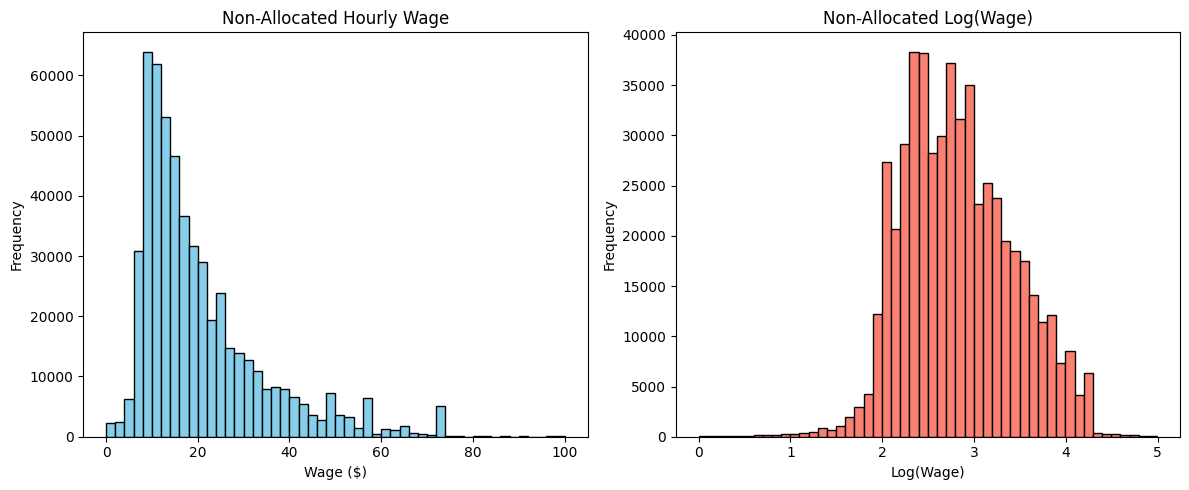

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
# Filter: Wage between 0-100 AND alloc01 is 0
plt.hist(df.loc[(df['wage'].between(0, 100)) & (df['alloc01'] == 0), 'wage'],
         bins=50, color='skyblue', edgecolor='black')
plt.title('Non-Allocated Hourly Wage')
plt.xlabel('Wage ($)')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
# Filter: Logwage between 0-5 AND alloc01 is 0
plt.hist(df.loc[(df['logwage'].between(0, 5)) & (df['alloc01'] == 0), 'logwage'],
         bins=50, color='salmon', edgecolor='black')
plt.title('Non-Allocated Log(Wage)')
plt.xlabel('Log(Wage)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()
plt.savefig('./figures/wage_distributions.png')

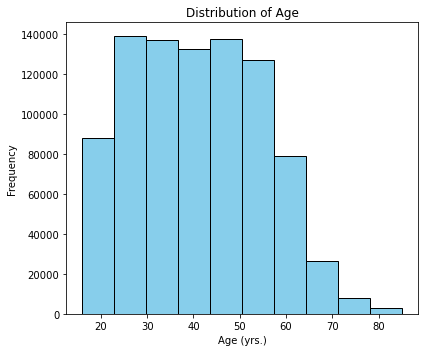

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.hist(df['age'], bins=10, color='skyblue', edgecolor='black')
plt.title('Distribution of Age')
plt.xlabel('Age (yrs.)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('age_distribution.png')

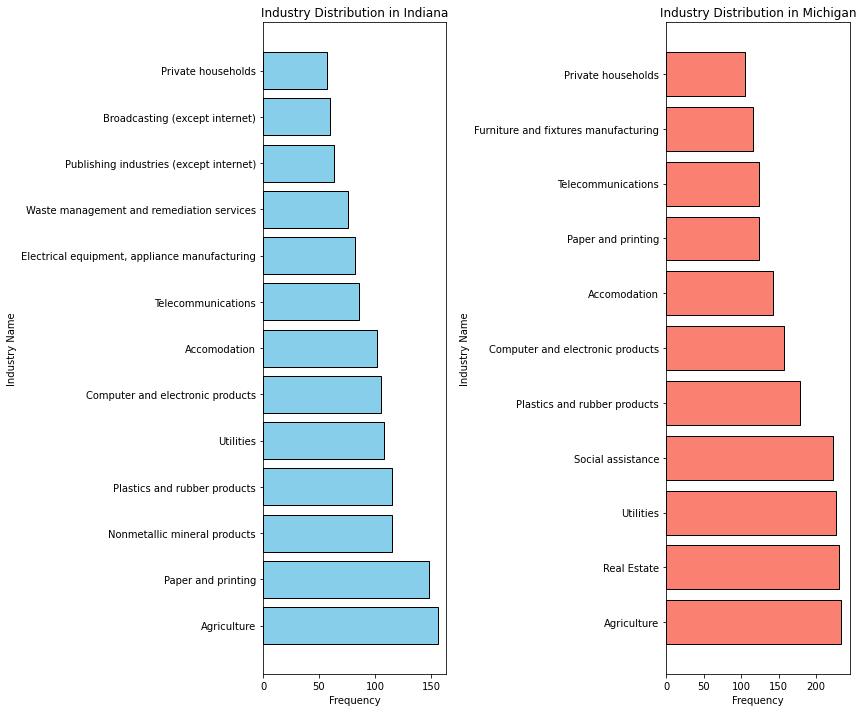

<Figure size 432x288 with 0 Axes>

In [17]:
import matplotlib.pyplot as plt


df = df_master

plt.figure(figsize=(12, 10))

plt.subplot(1, 2, 1)

# Filter: df['stfips'] == 18 (Indiana)

# dind02 is nominal categorical, so not histogram. Instead, bar plot of counts by industry code.
# only plot codes 1 - 50 for readability

indiana_counts = df.loc[df['stfips'] == 18, 'dind02'].value_counts().loc[1:50]

indiana_names = [industry_dict[code] for code in indiana_counts.index]

plt.barh(indiana_names, indiana_counts.values, color='skyblue', edgecolor='black')

plt.xlabel('Frequency')

plt.ylabel('Industry Name')

plt.title('Industry Distribution in Indiana')

plt.tight_layout()


# Do the same for Michigan (stfips == 26)
plt.subplot(1, 2, 2)
michigan_counts = df.loc[df['stfips'] == 26, 'dind02'].value_counts().loc[1:50]
michigan_names = [industry_dict[code] for code in michigan_counts.index]
plt.barh(michigan_names, michigan_counts.values, color='salmon', edgecolor='black')
plt.xlabel('Frequency')
plt.ylabel('Industry Name')
plt.title('Industry Distribution in Michigan')
plt.tight_layout()
plt.show()
plt.savefig('./industry_distributions.png')

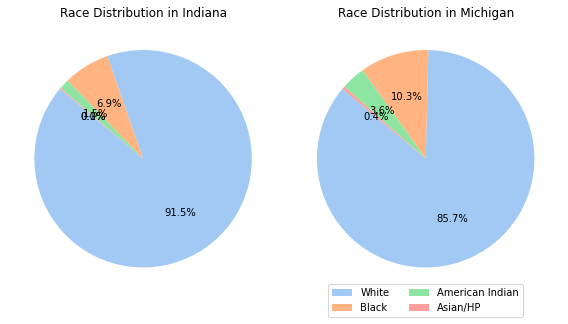

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
df = df_master
# plot race distribution as a pie chart for Indiana and Michigan side by side
# race code: 1=white, 2=black, 3=american indian, 4=asian/hp, 5=other
plt.figure(figsize=(8, 5))
# labels should be "White", "Black", "American Indian", "Asian/HP", "Other"
race_labels = ['White', 'Black', 'American Indian', 'Asian/HP', 'Other']
indiana_race_counts = df.loc[df['stfips'] == 18, 'race'].value_counts()
michigan_race_counts = df.loc[df['stfips'] == 26, 'race'].value_counts()
# move labels to legend to avoid overlap with pie slices
plt.subplot(1, 2, 1)
plt.pie(indiana_race_counts.values, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Race Distribution in Indiana')
plt.subplot(1, 2, 2)
plt.pie(michigan_race_counts.values, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Race Distribution in Michigan')
plt.legend(labels=race_labels, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.show()


<Figure size 1400x700 with 0 Axes>

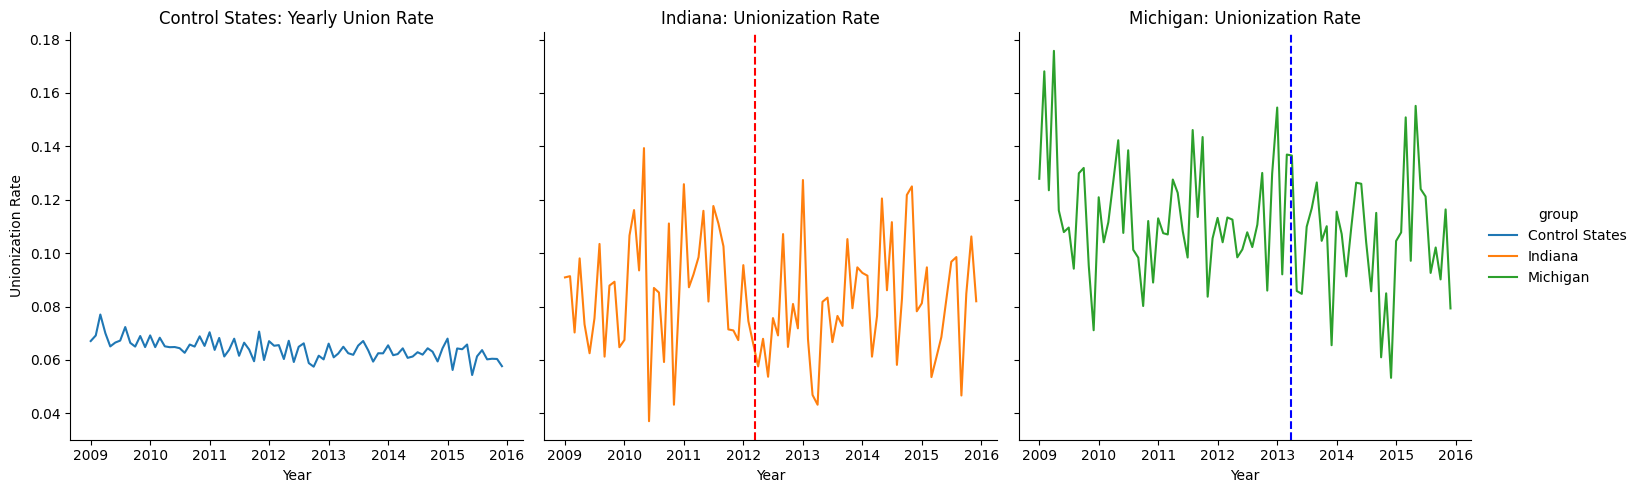

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Categorize states into Indiana, Michigan, and the Control Group
def categorize_state(fips):
    if fips == 18: return 'Indiana'
    if fips == 26: return 'Michigan'
    return 'Control States'

df['group'] = df['stfips'].apply(categorize_state)

# 2. Create a continuous date column for the x-axis
df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['intmonth'].astype(str) + '-01')

# 3. Calculate the monthly unionization rate for each group
trend_df = df.groupby(['date', 'group'])['unionmme01'].mean().reset_index()

# 4. Visualization
plt.figure(figsize=(14, 7))

# Use relplot for faceting (col='group' creates the separate plots)
g = sns.relplot(
    data=trend_df,
    x='date',
    y='unionmme01',
    col='group',
    hue='group',
    kind='line',
    markers=True,
    facet_kws={'sharey': True} # Keeps the y-axis scale the same for comparison
)

# Optional: Add the policy vertical lines to the specific plots
# Accessing individual axes: g.axes[0][0] is Indiana, [0][1] is Michigan, etc.
# Note: The order depends on the alphabetical order of your 'group' names

g.axes[0][0].set_title("Control States: Yearly Union Rate")

# Add Indiana Law Line to the Indiana plot
# (Assuming Indiana is index 1 if alphabetical: Control, Indiana, Michigan)
g.axes[0][1].axvline(pd.Timestamp('2012-03-14'), color='red', linestyle='--')
g.axes[0][1].set_title("Indiana: Unionization Rate")

# Add Michigan Law Line to the Michigan plot
g.axes[0][2].axvline(pd.Timestamp('2013-03-28'), color='blue', linestyle='--')
g.axes[0][2].set_title("Michigan: Unionization Rate")

g.set_axis_labels("Year", "Unionization Rate")
plt.show()

plt.savefig('./figures/union_trend_monthly.png')

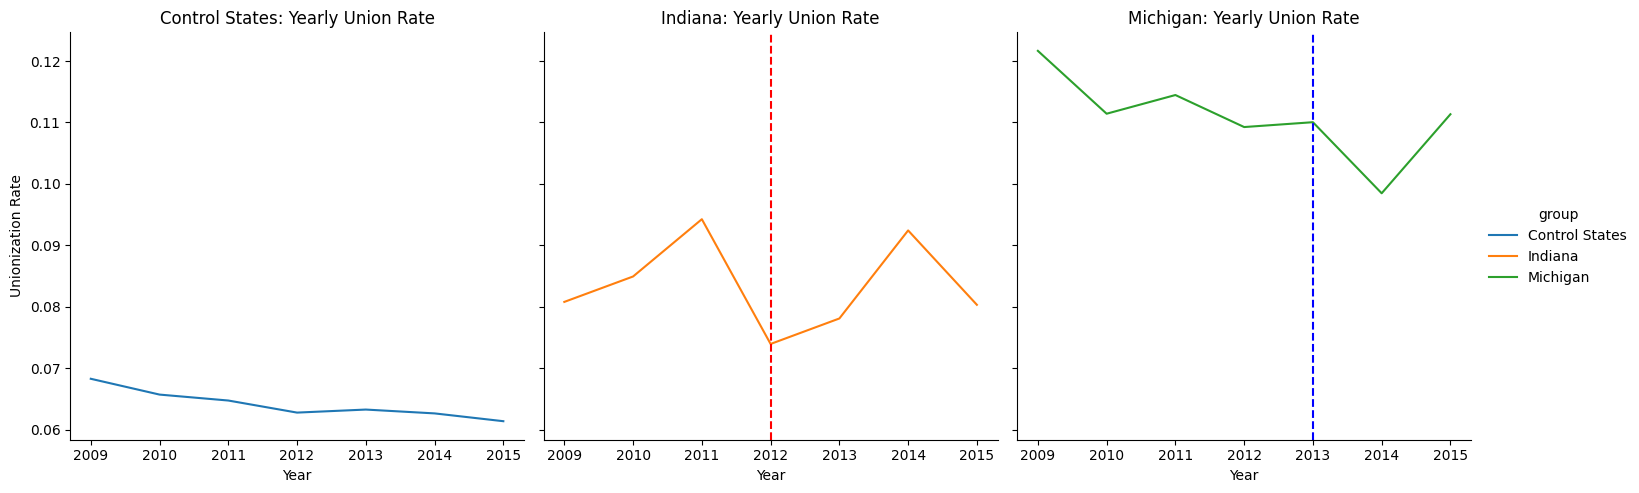

<Figure size 640x480 with 0 Axes>

In [ ]:
# 1. Group by Year and Group (Aggregation)
# This collapses all months into a single yearly mean
trend_df_year = df.groupby(['year', 'group'])['unionmme01'].mean().reset_index()

# 2. Visualization
g = sns.relplot(
    data=trend_df_year,
    x='year',            # Use 'year' instead of 'date'
    y='unionmme01',
    col='group',
    hue='group',
    kind='line',
    markers=True,
    facet_kws={'sharey': True}
)

# 3. Add Vertical Lines (Use integer year values now)
g.axes[0][0].set_title("Control States: Yearly Union Rate")
# Indiana Law (2012)
g.axes[0][1].axvline(2012, color='red', linestyle='--', label='RTW Passed')
g.axes[0][1].set_title("Indiana: Yearly Union Rate")

# Michigan Law (2013)
g.axes[0][2].axvline(2013, color='blue', linestyle='--', label='RTW Passed')
g.axes[0][2].set_title("Michigan: Yearly Union Rate")

g.set_axis_labels("Year", "Unionization Rate")
plt.show()

plt.savefig('./figures/union_trend_yearly.png')

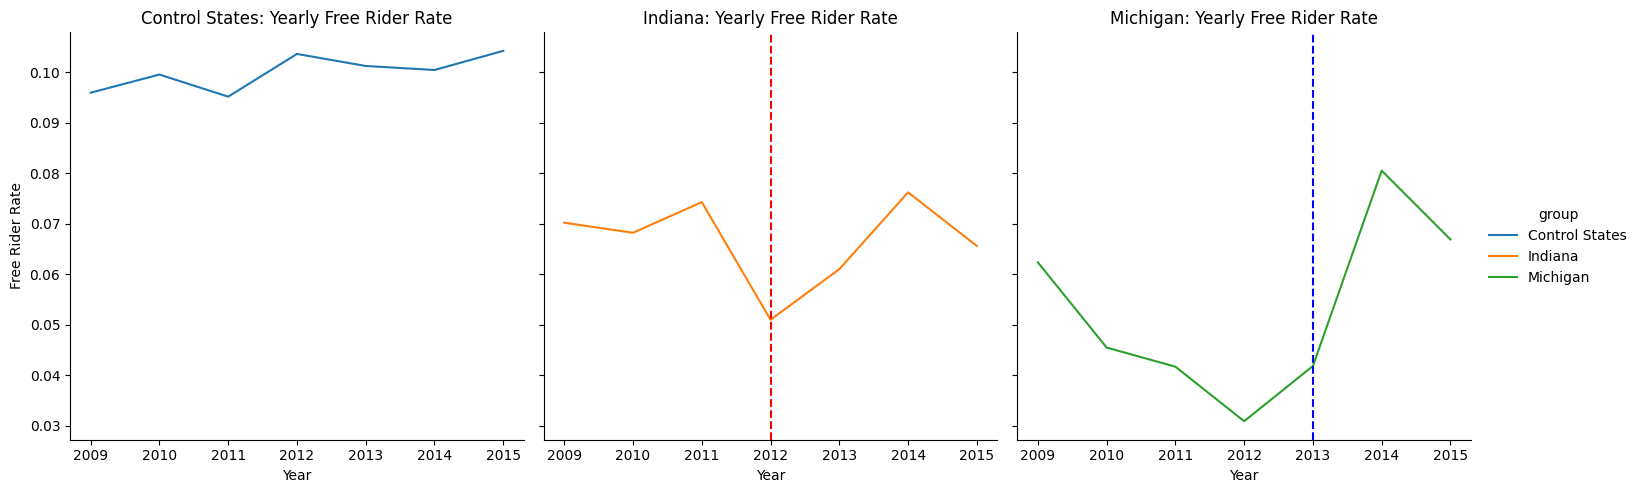

In [ ]:
# 1. Calculate the yearly average for the free rider variable
# We group by year and group, taking the mean of unionfr01
fr_trend_year = df.groupby(['year', 'group'])['unionfr01'].mean().reset_index()

# 2. Create the faceted line plot
g = sns.relplot(
    data=fr_trend_year,
    x='year',
    y='unionfr01',
    col='group',
    hue='group',
    kind='line',
    markers=True,
    facet_kws={'sharey': True}
)

# 3. Add policy vertical lines

g.axes[0][0].set_title("Control States: Yearly Free Rider Rate")

# Indiana (Passed in 2012)
g.axes[0][1].axvline(2012, color='red', linestyle='--', label='RTW Passed')
g.axes[0][1].set_title("Indiana: Yearly Free Rider Rate")

# Michigan (Passed in 2013)
g.axes[0][2].axvline(2013, color='blue', linestyle='--', label='RTW Passed')
g.axes[0][2].set_title("Michigan: Yearly Free Rider Rate")

# Labeling
g.set_axis_labels("Year", "Free Rider Rate")

plt.savefig('./free_rider_trend_yearly.png')
plt.show()

# Econometric Modeling

## Differences in Means (t-test)

In [7]:
import pandas as pd
from scipy import stats

df = df_master

# 1. Define State FIPS Codes
IN_FIPS = 18
MI_FIPS = 26

# 2. Define Variables
# Adjust column names based on whether the rename_dict has been applied
state_col = 'stfips'   # Change to 'State' if renamed
year_col = 'year'      # Change to 'Year' if renamed
month_col = 'intmonth'

vars_to_test = ['unionmme01', 'unionfr01', 'logwage']

# 3. Filter Datasets by State
df_in = df[df[state_col] == IN_FIPS].copy()
df_mi = df[df[state_col] == MI_FIPS].copy()

# 4. Create Pre/Post Masks based on Enactment Dates
# Indiana: April 2012
in_post_mask = (df_in[year_col] > 2012) | ((df_in[year_col] == 2012) & (df_in[month_col] >= 4))
in_pre = df_in[~in_post_mask]
in_post = df_in[in_post_mask]

# Michigan: April 2013
mi_post_mask = (df_mi[year_col] > 2013) | ((df_mi[year_col] == 2013) & (df_mi[month_col] >= 4))
mi_pre = df_mi[~mi_post_mask]
mi_post = df_mi[mi_post_mask]

# 5. Define T-Test Execution Function
def run_did_ttests_onesided(pre_data, post_data, state_name):
    print(f"{'='*45}")
    print(f" Differences in Means (1-Sided): {state_name} ")
    print(f"{'='*45}")

    for var in vars_to_test:
        pre_vals = pre_data[var].dropna()
        post_vals = post_data[var].dropna()

        pre_mean = pre_vals.mean()
        post_mean = post_vals.mean()
        diff = post_mean - pre_mean

        # Determine the direction for the one-sided test:
        # Scipy's ttest_ind compares (pre_vals - post_vals).
        # - For membership (unionmme01), we expect a drop: Pre > Post ('greater')
        # - For free riders (unionfr01), we expect a rise: Pre < Post ('less')
        # - For logwage, we expect a drop: Pre > Post ('greater')
        alt_test = 'greater' if var == 'unionmme01' or var == 'logwage' else 'less'

        # Welch's t-test with one-sided alternative
        t_stat, p_val = stats.ttest_ind(
            pre_vals, post_vals,
            equal_var=False,
            alternative=alt_test
        )

        print(f"Variable: {var} (Hypothesis: {'Decrease' if var == 'unionmme01' or var == 'logwage' else 'Increase'})")
        print(f"  Pre-RTW Mean:  {pre_mean:.4f} (n={len(pre_vals)})")
        print(f"  Post-RTW Mean: {post_mean:.4f} (n={len(post_vals)})")
        print(f"  Difference:    {diff:.4f}")
        print(f"  T-Statistic:   {t_stat:.4f}")
        print(f"  1-Sided P-Val: {p_val:.4f}\n")

# Run the updated tests
run_did_ttests_onesided(in_pre, in_post, "Indiana")
run_did_ttests_onesided(mi_pre, mi_post, "Michigan")

 Differences in Means (1-Sided): Indiana 
Variable: unionmme01 (Hypothesis: Decrease)
  Pre-RTW Mean:  0.0861 (n=6388)
  Post-RTW Mean: 0.0815 (n=7710)
  Difference:    -0.0046
  T-Statistic:   0.9900
  1-Sided P-Val: 0.1611

Variable: unionfr01 (Hypothesis: Increase)
  Pre-RTW Mean:  0.0678 (n=590)
  Post-RTW Mean: 0.0669 (n=673)
  Difference:    -0.0009
  T-Statistic:   0.0659
  1-Sided P-Val: 0.5263

Variable: logwage (Hypothesis: Decrease)
  Pre-RTW Mean:  2.7642 (n=5889)
  Post-RTW Mean: 2.8003 (n=7054)
  Difference:    0.0361
  T-Statistic:   -3.3459
  1-Sided P-Val: 0.9996

 Differences in Means (1-Sided): Michigan 
Variable: unionmme01 (Hypothesis: Decrease)
  Pre-RTW Mean:  0.1149 (n=12058)
  Post-RTW Mean: 0.1047 (n=8116)
  Difference:    -0.0102
  T-Statistic:   2.2842
  1-Sided P-Val: 0.0112

Variable: unionfr01 (Hypothesis: Increase)
  Pre-RTW Mean:  0.0461 (n=1453)
  Post-RTW Mean: 0.0639 (n=908)
  Difference:    0.0178
  T-Statistic:   -1.8111
  1-Sided P-Val: 0.0352

Va

## OLS Regressions

For subsequent regressions, need to take into account different universes. (possibly filter before, if the value is not na outside of universe).

In [ ]:
import statsmodels.formula.api as smf

df = df_master
reg_data = df[['unionmme01', 'rtw']].dropna()

formula = 'unionmme01 ~ rtw' # beta_0 included by default

# 3. Fit the OLS model
# Note: In policy evaluation (DiD) with state-level treatments, standard errors
# are typically clustered at the state level. If Zhang's paper specifies clustered
# standard errors, you would use: .fit(cov_type='cluster', cov_kwds={'groups': df['stfips']})
baseline_model = smf.ols(formula=formula, data=reg_data)
baseline_results = baseline_model.fit(cov_type='HC3')

# 4. Display the regression output
print("==============================================================================")
print("                            Union Membership on RTW")
print("==============================================================================")
print(baseline_results.summary())

                            Union Membership on RTW
                            OLS Regression Results                            
Dep. Variable:             unionmme01   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     7054.
Date:                Mon, 27 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:19:43   Log-Likelihood:                -16370.
No. Observations:              876214   AIC:                         3.274e+04
Df Residuals:                  876212   BIC:                         3.277e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------


In [ ]:
reg_data = df[['unionfr01', 'rtw']].dropna()

formula = 'unionfr01 ~ rtw' # beta_0 included by default

# 3. Fit the OLS model
# Note: In policy evaluation (DiD) with state-level treatments, standard errors
# are typically clustered at the state level. If Zhang's paper specifies clustered
# standard errors, you would use: .fit(cov_type='cluster', cov_kwds={'groups': df['stfips']})
baseline_model = smf.ols(formula=formula, data=reg_data)
baseline_results = baseline_model.fit(cov_type='HC3')

# 4. Display the regression output
print("==============================================================================")
print("                            Free Riders on RTW")
print("==============================================================================")
print(baseline_results.summary())

                            Free Riders on RTW
                            OLS Regression Results                            
Dep. Variable:              unionfr01   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     539.8
Date:                Mon, 27 Apr 2026   Prob (F-statistic):          6.42e-119
Time:                        19:19:28   Log-Likelihood:                -12617.
No. Observations:               63596   AIC:                         2.524e+04
Df Residuals:                   63594   BIC:                         2.526e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Inter

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# 1. Filter the sample for union-covered workers only
# Note: Use 'Union-covered' if you applied the rename_dict, otherwise use 'unioncov01'
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]

# 2. Select the relevant variables and drop missing values
reg_data_wage = union_covered_df[['logwage', 'rtw']].dropna()

# 3. Define the regression formula
formula_wage = 'logwage ~ rtw'

# 4. Fit the OLS model
# Using HC3 robust standard errors to match your previous regression setup
wage_model = smf.ols(formula=formula_wage, data=reg_data_wage)
wage_results = wage_model.fit(cov_type='HC3')

# 5. Display the regression output
print("==============================================================================")
print("                 Log Wage on RTW (Union-Covered Workers Only)                 ")
print("==============================================================================")
print(wage_results.summary())

                 Log Wage on RTW (Union-Covered Workers Only)                 
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     21.30
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           3.93e-06
Time:                        18:43:15   Log-Likelihood:                -34534.
No. Observations:               40274   AIC:                         6.907e+04
Df Residuals:                   40272   BIC:                         6.909e+04
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# 1. Filter the sample for non-union-covered workers only
# Note: Use 'Union-covered' if you applied the rename_dict, otherwise use 'unioncov01'

non_union_covered_df = df[(df['unioncov01'] == 0) & (df['alloc01'] == 0)]

# 2. Select the relevant variables and drop missing values
reg_data_wage = non_union_covered_df[['logwage', 'rtw']].dropna()

# 3. Define the regression formula
formula_wage = 'logwage ~ rtw'

# 4. Fit the OLS model
# Using HC3 robust standard errors to match your previous regression setup
wage_model = smf.ols(formula=formula_wage, data=reg_data_wage)
wage_results = wage_model.fit(cov_type='HC3')

# 5. Display the regression output
print("==============================================================================")
print("                 Log Wage on RTW (Non-Covered Workers Only)                 ")
print("==============================================================================")
print(wage_results.summary())

                 Log Wage on RTW (Non-Covered Workers Only)                 
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     4016.
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        18:45:31   Log-Likelihood:            -5.0158e+05
No. Observations:              496292   AIC:                         1.003e+06
Df Residuals:                  496290   BIC:                         1.003e+06
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------

In [ ]:
import statsmodels.formula.api as smf

# 1. Filter the sample for union-covered workers only, and exclude allocated wages
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]

# 2. Select the relevant variables and drop missing values
# Note: Ensure you use 'unionmme01' to match your dataframe's column name
reg_data_wage_ext = union_covered_df[['logwage', 'rtw', 'unionmme01']].dropna()

# 3. Define the regression formula with the additional regressor
formula_wage_ext = 'logwage ~ rtw + unionmme01'

# 4. Fit the OLS model
# Using HC3 robust standard errors
wage_model_ext = smf.ols(formula=formula_wage_ext, data=reg_data_wage_ext)
wage_results_ext = wage_model_ext.fit(cov_type='HC3')

# 5. Display the regression output
print("==============================================================================")
print("          Log Wage on RTW and Union Membership (Union-Covered Only)           ")
print("==============================================================================")
print(wage_results_ext.summary())

          Log Wage on RTW and Union Membership (Union-Covered Only)           
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     97.81
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           4.22e-43
Time:                        19:05:48   Log-Likelihood:                -34431.
No. Observations:               40274   AIC:                         6.887e+04
Df Residuals:                   40271   BIC:                         6.889e+04
Df Model:                           2                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------

## "Basic" DID

In [ ]:
import statsmodels.formula.api as smf
import numpy as np

df = df_master
# ==============================================================================
# STEP 1: CONSTRUCT STAGGERED DID VARIABLES
# ==============================================================================
df['treatment_s'] = df['stfips'].isin([18, 26]).astype(int)

# 1b. Create the state-specific 'after_t' indicator
# Logic: 1 if (Indiana & >= April 2012) OR (Not Indiana & >= April 2013)
cond_indiana_post = (df['stfips'] == 18) & (
    (df['year'] > 2012) | ((df['year'] == 2012) & (df['intmonth'] >= 4))
)

cond_others_post = (df['stfips'] != 18) & (
    (df['year'] > 2013) | ((df['year'] == 2013) & (df['intmonth'] >= 4))
)
cond = cond_indiana_post | cond_others_post

df['after_t'] = (cond).astype(int)

df['rtw2'] = df['treatment_s'] * df['after_t']
#assert df['rtw'].equals(df['rtw2']), "The columns do not match!"

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================

# Replicating Zhang's primary Union Membership regression
variables_kept = ['unionmme01', 'rtw', 'treatment_s', 'after_t']
df_did = df[variables_kept].dropna()


# ==============================================================================
# STEP 4: FIT MODEL WITH ROBUST STANDARD ERRORS
# ==============================================================================

# Equation 4 from the report: Y = B0 + B1(rtw) + B2(treatment) + B3(after)
formula_zhang = 'unionmme01 ~ rtw + treatment_s + after_t'

did_model = smf.ols(formula_zhang, data=df_did).fit(cov_type='HC3')


# ==============================================================================
# STEP 5: OUTPUT SUMMARY
# ==============================================================================

print("=== Union Membership ===")
print(did_model.summary())

=== Zhang's Staggered DID Model (Equation 4) ===
                            OLS Regression Results                            
Dep. Variable:             unionmme01   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2610.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        12:46:18   Log-Likelihood:                -15977.
No. Observations:              876214   AIC:                         3.196e+04
Df Residuals:                  876210   BIC:                         3.201e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
I

In [ ]:
import statsmodels.formula.api as smf
import numpy as np

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================

# Replicating Zhang's primary Union Free-Rider regression
variables_kept = ['unionfr01', 'rtw', 'treatment_s', 'after_t']
df_did = df[variables_kept].dropna()


# ==============================================================================
# STEP 4: FIT MODEL WITH ROBUST STANDARD ERRORS
# ==============================================================================

# Equation 4 from the report: Y = B0 + B1(rtw) + B2(treatment) + B3(after)
formula_zhang = 'unionfr01 ~ rtw + treatment_s + after_t'

did_model = smf.ols(formula_zhang, data=df_did).fit(cov_type='HC3')


# ==============================================================================
# STEP 5: OUTPUT SUMMARY
# ==============================================================================

print("=== Union Free-Rider ===")
print(did_model.summary())

=== Union Free-Rider ===
                            OLS Regression Results                            
Dep. Variable:              unionfr01   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     218.1
Date:                Thu, 30 Apr 2026   Prob (F-statistic):          9.59e-141
Time:                        12:58:37   Log-Likelihood:                -12558.
No. Observations:               63596   AIC:                         2.512e+04
Df Residuals:                   63592   BIC:                         2.516e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       0.0819   

In [ ]:
import statsmodels.formula.api as smf
import numpy as np

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================

# Replicating Zhang's primary Union-Covered Wages regression
variables_kept = ['logwage', 'rtw', 'treatment_s', 'after_t']
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
df_did = union_covered_df[variables_kept].dropna()


# ==============================================================================
# STEP 4: FIT MODEL WITH ROBUST STANDARD ERRORS
# ==============================================================================

# Equation 4 from the report: Y = B0 + B1(rtw) + B2(treatment) + B3(after)
formula_zhang = 'logwage ~ rtw + treatment_s + after_t'

did_model = smf.ols(formula_zhang, data=df_did).fit(cov_type='HC3')


# ==============================================================================
# STEP 5: OUTPUT SUMMARY
# ==============================================================================

print("=== Union-Covered Wages ===")
print(did_model.summary())

=== Union-Covered Wages ===
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     43.40
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           5.43e-28
Time:                        13:01:50   Log-Likelihood:                -34481.
No. Observations:               40274   AIC:                         6.897e+04
Df Residuals:                   40270   BIC:                         6.900e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       3.0250

In [ ]:
import statsmodels.formula.api as smf
import numpy as np

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================

# Replicating Zhang's primary Non-Union-Covered Wages regression
variables_kept = ['logwage', 'rtw', 'treatment_s', 'after_t']
non_union_covered_df = df[(df['unioncov01'] == 0) & (df['alloc01'] == 0)]
df_did = non_union_covered_df[variables_kept].dropna()


# ==============================================================================
# STEP 4: FIT MODEL WITH ROBUST STANDARD ERRORS
# ==============================================================================

# Equation 4 from the report: Y = B0 + B1(rtw) + B2(treatment) + B3(after)
formula_zhang = 'logwage ~ rtw + treatment_s + after_t'

did_model = smf.ols(formula_zhang, data=df_did).fit(cov_type='HC3')


# ==============================================================================
# STEP 5: OUTPUT SUMMARY
# ==============================================================================

print("=== Non-Union-Covered Wages ===")
print(did_model.summary())

=== Non-Union-Covered Wages ===
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                  0.011
Method:                 Least Squares   F-statistic:                     1798.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        13:03:38   Log-Likelihood:            -5.0091e+05
No. Observations:              496292   AIC:                         1.002e+06
Df Residuals:                  496288   BIC:                         1.002e+06
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept       2.

In [ ]:
import statsmodels.formula.api as smf
import numpy as np

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================

# Replicating Zhang's primary Union-Covered Wages regression
variables_kept = ['logwage', 'rtw', 'unionmme01',  'treatment_s', 'after_t']
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
df_did = union_covered_df[variables_kept].dropna()


# ==============================================================================
# STEP 4: FIT MODEL WITH ROBUST STANDARD ERRORS
# ==============================================================================

# Equation 4 from the report: Y = B0 + B1(rtw) + B2(treatment) + B3(after)
formula_zhang = 'logwage ~ rtw + unionmme01 + treatment_s + after_t'

did_model = smf.ols(formula_zhang, data=df_did).fit(cov_type='HC3')


# ==============================================================================
# STEP 5: OUTPUT SUMMARY
# ==============================================================================

print("=== Union-Covered Wages On RTW and Membership ===")
print(did_model.summary())

=== Union-Covered Wages On RTW and Membership ===
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     76.83
Date:                Thu, 30 Apr 2026   Prob (F-statistic):           5.06e-65
Time:                        13:06:52   Log-Likelihood:                -34375.
No. Observations:               40274   AIC:                         6.876e+04
Df Residuals:                   40269   BIC:                         6.880e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------


## DID + Fixed Effects

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE FIXED EFFECTS COLUMNS
# ==============================================================================
# Based on common CPS naming conventions used in your notebook:
# State FE: 'stfips'
# Year FE: 'year'
# Industry FE: 'major_ind' (or 'ind02' depending on your specific column)

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & SELECT VARIABLES
# ==============================================================================

# Replicating the Union Membership regression with full controls
# Note: We include the FE columns in the slice so dropna() accounts for them.
variables_kept = ['unionmme01', 'rtw', 'stfips', 'year', 'dind02']
df_expanded = df[variables_kept].dropna()

# ==============================================================================
# STEP 4: FIT THE FIXED EFFECTS MODEL
# ==============================================================================

# Formula: Y ~ Treatment + C(State) + C(Year) + C(Industry)
# The C() operator automatically creates dummy variables for every category.
formula_fe = 'unionmme01 ~ rtw + C(stfips) + C(year) + C(dind02)'

# Fitting with Robust Standard Errors (HC3)
# Note: For large datasets with many fixed effects, this may take a moment to compute.
fe_model = smf.ols(formula_fe, data=df_expanded).fit(cov_type='HC3')

In [ ]:
# Create a clean dataframe with the core statistics
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

           Coefficient   Std Err    t-stat   P-value
Intercept     0.015936  0.004126  3.862513  0.000112
rtw          -0.007450  0.003168 -2.351461  0.018700
                            OLS Regression Results                            
Dep. Variable:             unionmme01   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     401.5
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:19:11   Log-Likelihood:                 13339.
No. Observations:              876214   AIC:                        -2.646e+04
Df Residuals:                  876106   BIC:                        -2.520e+04
Df Model:                         107                                         
Covariance Type:                  HC3                                         


In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE FIXED EFFECTS COLUMNS
# ==============================================================================
# Based on common CPS naming conventions used in your notebook:
# State FE: 'stfips'
# Year FE: 'year'
# Industry FE: 'major_ind' (or 'ind02' depending on your specific column)

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & SELECT VARIABLES
# ==============================================================================

# Replicating the Union Membership regression with full controls
# Note: We include the FE columns in the slice so dropna() accounts for them.
variables_kept = ['unionfr01', 'rtw', 'stfips', 'year', 'dind02']
df_expanded = df[variables_kept].dropna()

# ==============================================================================
# STEP 4: FIT THE FIXED EFFECTS MODEL
# ==============================================================================

# Formula: Y ~ Treatment + C(State) + C(Year) + C(Industry)
# The C() operator automatically creates dummy variables for every category.
formula_fe = 'unionfr01 ~ rtw + C(stfips) + C(year) + C(dind02)'

# Fitting with Robust Standard Errors (HC3)
# Note: For large datasets with many fixed effects, this may take a moment to compute.
fe_model = smf.ols(formula_fe, data=df_expanded).fit(cov_type='HC3')

In [ ]:
# Create a clean dataframe with the core statistics
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

           Coefficient   Std Err    t-stat       P-value
Intercept     0.201956  0.036115  5.592042  2.244140e-08
rtw           0.012394  0.008226  1.506728  1.318803e-01
                            OLS Regression Results                            
Dep. Variable:              unionfr01   R-squared:                       0.062
Model:                            OLS   Adj. R-squared:                  0.060
Method:                 Least Squares   F-statistic:                     25.66
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        15:20:27   Log-Likelihood:                -10932.
No. Observations:               63596   AIC:                         2.208e+04
Df Residuals:                   63488   BIC:                         2.306e+04
Df Model:                         107                                         
Covariance Type:                  HC3                                         


In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE FIXED EFFECTS COLUMNS
# ==============================================================================
# Based on common CPS naming conventions used in your notebook:
# State FE: 'stfips'
# Year FE: 'year'
# Industry FE: 'major_ind' (or 'ind02' depending on your specific column)

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & SELECT VARIABLES
# ==============================================================================

# Replicating the Union Membership regression with full controls
# Note: We include the FE columns in the slice so dropna() accounts for them.
variables_kept = ['logwage', 'rtw', 'stfips', 'year', 'dind02']
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
df_expanded = union_covered_df[variables_kept].dropna()

# ==============================================================================
# STEP 4: FIT THE FIXED EFFECTS MODEL
# ==============================================================================

# Formula: Y ~ Treatment + C(State) + C(Year) + C(Industry)
# The C() operator automatically creates dummy variables for every category.
formula_fe = 'logwage ~ rtw + C(stfips) + C(year) + C(dind02)'

# Fitting with Robust Standard Errors (HC3)
# Note: For large datasets with many fixed effects, this may take a moment to compute.
fe_model = smf.ols(formula_fe, data=df_expanded).fit(cov_type='HC3')

In [ ]:
# Create a clean dataframe with the core statistics
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

           Coefficient   Std Err     t-stat   P-value
Intercept     2.410510  0.060560  39.803609  0.000000
rtw           0.025231  0.022056   1.143988  0.252628
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.225
Method:                 Least Squares   F-statistic:                     124.3
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:34:45   Log-Likelihood:                -29358.
No. Observations:               40274   AIC:                         5.893e+04
Df Residuals:                   40166   BIC:                         5.986e+04
Df Model:                         107                                         
Covariance Type:                  HC3                                         


In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE FIXED EFFECTS COLUMNS
# ==============================================================================
# Based on common CPS naming conventions used in your notebook:
# State FE: 'stfips'
# Year FE: 'year'
# Industry FE: 'major_ind' (or 'ind02' depending on your specific column)

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & SELECT VARIABLES
# ==============================================================================

# Replicating the Union Membership regression with full controls
# Note: We include the FE columns in the slice so dropna() accounts for them.
variables_kept = ['logwage', 'rtw', 'stfips', 'year', 'dind02']
non_union_covered_df = df[(df['unioncov01'] == 0) & (df['alloc01'] == 0)]
df_expanded = non_union_covered_df[variables_kept].dropna()

# ==============================================================================
# STEP 4: FIT THE FIXED EFFECTS MODEL
# ==============================================================================

# Formula: Y ~ Treatment + C(State) + C(Year) + C(Industry)
# The C() operator automatically creates dummy variables for every category.
formula_fe = 'logwage ~ rtw + C(stfips) + C(year) + C(dind02)'

# Fitting with Robust Standard Errors (HC3)
# Note: For large datasets with many fixed effects, this may take a moment to compute.
fe_model = smf.ols(formula_fe, data=df_expanded).fit(cov_type='HC3')

In [ ]:
# Create a clean dataframe with the core statistics
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

           Coefficient   Std Err      t-stat   P-value
Intercept     2.223421  0.014545  152.860805  0.000000
rtw           0.000937  0.008523    0.109887  0.912499
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.219
Method:                 Least Squares   F-statistic:                     1407.
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:36:11   Log-Likelihood:            -4.4208e+05
No. Observations:              496292   AIC:                         8.844e+05
Df Residuals:                  496184   BIC:                         8.856e+05
Df Model:                         107                                         
Covariance Type:                  HC3                                         


In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE FIXED EFFECTS COLUMNS
# ==============================================================================
# Based on common CPS naming conventions used in your notebook:
# State FE: 'stfips'
# Year FE: 'year'
# Industry FE: 'major_ind' (or 'ind02' depending on your specific column)

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & SELECT VARIABLES
# ==============================================================================

# Replicating the Union Membership regression with full controls
# Note: We include the FE columns in the slice so dropna() accounts for them.
variables_kept = ['logwage', 'unionmme01', 'rtw', 'stfips', 'year', 'dind02']
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
df_expanded = union_covered_df[variables_kept].dropna()

# ==============================================================================
# STEP 4: FIT THE FIXED EFFECTS MODEL
# ==============================================================================

# Formula: Y ~ Treatment + C(State) + C(Year) + C(Industry)
# The C() operator automatically creates dummy variables for every category.
formula_fe = 'logwage ~ rtw + unionmme01 + C(stfips) + C(year) + C(dind02)'

# Fitting with Robust Standard Errors (HC3)
# Note: For large datasets with many fixed effects, this may take a moment to compute.
fe_model = smf.ols(formula_fe, data=df_expanded).fit(cov_type='HC3')

In [ ]:
# Create a clean dataframe with the core statistics
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'unionmme01', 'rtw']])
print(fe_model.summary().tables[0])

            Coefficient   Std Err     t-stat       P-value
Intercept      2.348411  0.061466  38.206461  0.000000e+00
unionmme01     0.076320  0.009907   7.703512  1.323765e-14
rtw            0.025688  0.022062   1.164379  2.442703e-01
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.229
Model:                            OLS   Adj. R-squared:                  0.226
Method:                 Least Squares   F-statistic:                     123.7
Date:                Thu, 30 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:38:08   Log-Likelihood:                -29319.
No. Observations:               40274   AIC:                         5.886e+04
Df Residuals:                   40165   BIC:                         5.979e+04
Df Model:                         108                                         
Covariance Type:                  HC3                

## DID + FE + Controls

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE VARIABLE GROUPS
# ==============================================================================
# Fixed Effects variables
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Demographic Control variables (Vector x_i)
# Note: education and race are categorical; others are binary or continuous.
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01',
    'marital01', 'metro01', 'C(race)', 'male01'
]

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================
# We define the subset of columns needed to ensure dropna() cleans the sample correctly.
# Using 'unionmme01' as the dependent variable Y.
model_cols = ['unionmme01', 'rtw'] + ['stfips', 'year', 'dind02'] + \
             ['age', 'agesq', 'education', 'hispanic01', 'marital01', 'metro01', 'race', 'male01']

df_final = df[model_cols].dropna()

# ==============================================================================
# STEP 4: CONSTRUCT FORMULA AND FIT MODEL
# ==============================================================================
# Combining all elements into the R-style formula
formula_str = 'unionmme01 ~ rtw + ' + ' + '.join(fe_vars + controls)
print("Constructed Formula:")
print(formula_str)

# Fit with Heteroscedasticity-robust standard errors (HC3)
fe_model = smf.ols(formula_str, data=df_final).fit(cov_type='HC3')

# ==============================================================================
# STEP 5: OUTPUT RESULTS
# ==============================================================================
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

Constructed Formula:
unionmme01 ~ rtw + C(stfips) + C(year) + C(dind02) + age + agesq + C(education) + hispanic01 + marital01 + metro01 + C(race) + male01
           Coefficient   Std Err     t-stat       P-value
Intercept    -0.096162  0.004577 -21.010110  5.301175e-98
rtw          -0.007327  0.003146  -2.328712  1.987434e-02
                            OLS Regression Results                            
Dep. Variable:             unionmme01   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     373.8
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        13:48:15   Log-Likelihood:                 15980.
No. Observations:              868713   AIC:                        -3.172e+04
Df Residuals:                  868591   BIC:                        -3.029e+04
Df Model:                         121  

In [16]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE VARIABLE GROUPS
# ==============================================================================
# Fixed Effects variables
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Demographic Control variables (Vector x_i)
# Note: education and race are categorical; others are binary or continuous.
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01',
    'marital01', 'metro01', 'C(race)', 'male01'
]

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================
# We define the subset of columns needed to ensure dropna() cleans the sample correctly.
# Using 'unionfr01' as the dependent variable Y.
model_cols = ['unionfr01', 'rtw'] + ['stfips', 'year', 'dind02'] + \
             ['age', 'agesq', 'education', 'hispanic01', 'marital01', 'metro01', 'race', 'male01']

df_final = df[model_cols].dropna()

# ==============================================================================
# STEP 4: CONSTRUCT FORMULA AND FIT MODEL
# ==============================================================================
# Combining all elements into the R-style formula
formula_str = 'unionfr01 ~ rtw + ' + ' + '.join(fe_vars + controls)
print("Constructed Formula:")
print(formula_str)

# Fit with Heteroscedasticity-robust standard errors (HC3)
fe_model = smf.ols(formula_str, data=df_final).fit(cov_type='HC3')

# ==============================================================================
# STEP 5: OUTPUT RESULTS
# ==============================================================================
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

Constructed Formula:
unionfr01 ~ rtw + C(stfips) + C(year) + C(dind02) + age + agesq + C(education) + hispanic01 + marital01 + metro01 + C(race) + male01
           Coefficient   Std Err    t-stat       P-value
Intercept     0.332927  0.038421  8.665200  4.507207e-18
rtw           0.013448  0.008168  1.646458  9.966960e-02
                            OLS Regression Results                            
Dep. Variable:              unionfr01   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     25.02
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        14:03:52   Log-Likelihood:                -10466.
No. Observations:               63163   AIC:                         2.118e+04
Df Residuals:                   63041   BIC:                         2.228e+04
Df Model:                         121      

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE VARIABLE GROUPS
# ==============================================================================
# Fixed Effects variables
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Demographic Control variables (Vector x_i)
# Note: education and race are categorical; others are binary or continuous.
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01',
    'marital01', 'metro01', 'C(race)', 'male01'
]

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================
# We define the subset of columns needed to ensure dropna() cleans the sample correctly.
# Using 'logwage' as the dependent variable Y.
model_cols = ['logwage', 'rtw'] + ['stfips', 'year', 'dind02'] + \
             ['age', 'agesq', 'education', 'hispanic01', 'marital01', 'metro01', 'race', 'male01']
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
df_final = union_covered_df[model_cols].dropna()

# ==============================================================================
# STEP 4: CONSTRUCT FORMULA AND FIT MODEL
# ==============================================================================
# Combining all elements into the R-style formula
formula_str = 'logwage ~ rtw + ' + ' + '.join(fe_vars + controls)
print("Constructed Formula:")
print(formula_str)

# Fit with Heteroscedasticity-robust standard errors (HC3)
fe_model = smf.ols(formula_str, data=df_final).fit(cov_type='HC3')

# ==============================================================================
# STEP 5: OUTPUT RESULTS
# ==============================================================================
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

Constructed Formula:
logwage ~ rtw + C(stfips) + C(year) + C(dind02) + age + agesq + C(education) + hispanic01 + marital01 + metro01 + C(race) + male01
           Coefficient   Std Err     t-stat       P-value
Intercept     1.202004  0.058109  20.685329  4.695636e-95
rtw           0.021911  0.020499   1.068890  2.851194e-01
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     268.8
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        14:06:33   Log-Likelihood:                -25417.
No. Observations:               39991   AIC:                         5.108e+04
Df Residuals:                   39869   BIC:                         5.213e+04
Df Model:                         121     

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE VARIABLE GROUPS
# ==============================================================================
# Fixed Effects variables
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Demographic Control variables (Vector x_i)
# Note: education and race are categorical; others are binary or continuous.
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01',
    'marital01', 'metro01', 'C(race)', 'male01'
]

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================
# We define the subset of columns needed to ensure dropna() cleans the sample correctly.
# Using 'logwage' as the dependent variable Y.
model_cols = ['logwage', 'rtw'] + ['stfips', 'year', 'dind02'] + \
             ['age', 'agesq', 'education', 'hispanic01', 'marital01', 'metro01', 'race', 'male01']
non_union_covered_df = df[(df['unioncov01'] == 0) & (df['alloc01'] == 0)]
df_final = non_union_covered_df[model_cols].dropna()

# ==============================================================================
# STEP 4: CONSTRUCT FORMULA AND FIT MODEL
# ==============================================================================
# Combining all elements into the R-style formula
formula_str = 'logwage ~ rtw + ' + ' + '.join(fe_vars + controls)
print("Constructed Formula:")
print(formula_str)

# Fit with Heteroscedasticity-robust standard errors (HC3)
fe_model = smf.ols(formula_str, data=df_final).fit(cov_type='HC3')

# ==============================================================================
# STEP 5: OUTPUT RESULTS
# ==============================================================================
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(fe_model.summary().tables[0])

Constructed Formula:
logwage ~ rtw + C(stfips) + C(year) + C(dind02) + age + agesq + C(education) + hispanic01 + marital01 + metro01 + C(race) + male01
           Coefficient   Std Err     t-stat   P-value
Intercept     1.077887  0.014656  73.547434  0.000000
rtw           0.004812  0.007281   0.660899  0.508677
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.408
Model:                            OLS   Adj. R-squared:                  0.408
Method:                 Least Squares   F-statistic:                     3002.
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        14:07:37   Log-Likelihood:            -3.6949e+05
No. Observations:              491605   AIC:                         7.392e+05
Df Residuals:                  491483   BIC:                         7.406e+05
Df Model:                         121                 

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE VARIABLE GROUPS
# ==============================================================================
# Fixed Effects variables
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Demographic Control variables (Vector x_i)
# Note: education and race are categorical; others are binary or continuous.
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01',
    'marital01', 'metro01', 'C(race)', 'male01'
]

# ==============================================================================
# STEP 2 & 3: FILTER UNIVERSE & HANDLE NaNs
# ==============================================================================
# We define the subset of columns needed to ensure dropna() cleans the sample correctly.
# Using 'logwage' as the dependent variable Y.
model_cols = ['logwage', 'rtw', 'unionmme01'] + ['stfips', 'year', 'dind02'] + \
             ['age', 'agesq', 'education', 'hispanic01', 'marital01', 'metro01', 'race', 'male01']
union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
df_final = union_covered_df[model_cols].dropna()

# ==============================================================================
# STEP 4: CONSTRUCT FORMULA AND FIT MODEL
# ==============================================================================
# Combining all elements into the R-style formula
formula_str = 'logwage ~ rtw + unionmme01 + ' + ' + '.join(fe_vars + controls)
print("Constructed Formula:")
print(formula_str)

# Fit with Heteroscedasticity-robust standard errors (HC3)
fe_model = smf.ols(formula_str, data=df_final).fit(cov_type='HC3')

# ==============================================================================
# STEP 5: OUTPUT RESULTS
# ==============================================================================
res_df = pd.DataFrame({
    'Coefficient': fe_model.params,
    'Std Err': fe_model.bse,
    't-stat': fe_model.tvalues,
    'P-value': fe_model.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw', 'unionmme01']])
print(fe_model.summary().tables[0])

Constructed Formula:
logwage ~ rtw + unionmme01 + C(stfips) + C(year) + C(dind02) + age + agesq + C(education) + hispanic01 + marital01 + metro01 + C(race) + male01
            Coefficient   Std Err     t-stat       P-value
Intercept      1.158769  0.058567  19.785461  3.972489e-87
rtw            0.022430  0.020507   1.093812  2.740376e-01
unionmme01     0.066934  0.008875   7.541982  4.628822e-14
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.354
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     267.5
Date:                Fri, 01 May 2026   Prob (F-statistic):               0.00
Time:                        14:09:21   Log-Likelihood:                -25381.
No. Observations:               39991   AIC:                         5.101e+04
Df Residuals:                   39868   BIC:  

# Robustness Checks

## Heterogeneous Effects

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE COMMON MODEL ELEMENTS
# ==============================================================================
# Demographic Vector (x_i)
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01', 
    'marital01', 'metro01', 'C(race)', 'male01'
]

# Fixed Effects (State, Year, Industry)
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Combine into formula string
formula_str = 'unionmme01 ~ rtw + ' + ' + '.join(fe_vars + controls)

# Define the set of control states (Excluding both IN=18 and MI=26)
control_states = df[~df['stfips'].isin([18, 26])]['stfips'].unique()


# ==============================================================================
# STEP 2: INDIANA-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Indiana (18) + Control States
df_in_only = df[df['stfips'].isin([18] + list(control_states))].copy()

# Fit the model
model_in = smf.ols(formula_str, data=df_in_only.dropna(subset=['unionmme01', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: MICHIGAN-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Michigan (26) + Control States
df_mi_only = df[df['stfips'].isin([26] + list(control_states))].copy()

# Fit the model
model_mi = smf.ols(formula_str, data=df_mi_only.dropna(subset=['unionmme01', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

In [3]:
res_df = pd.DataFrame({
    'Coefficient': model_in.params,
    'Std Err': model_in.bse,
    't-stat': model_in.tvalues,
    'P-value': model_in.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_in.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_mi.params,
    'Std Err': model_mi.bse,
    't-stat': model_mi.tvalues,
    'P-value': model_mi.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_mi.summary().tables[0])

           Coefficient   Std Err     t-stat       P-value
Intercept    -0.098414  0.005617 -17.521151  9.880609e-69
rtw          -0.001741  0.004511  -0.385978  6.995128e-01
                            OLS Regression Results                            
Dep. Variable:             unionmme01   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.079
Method:                 Least Squares   F-statistic:                     359.9
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        10:55:51   Log-Likelihood:                 21609.
No. Observations:              848539   AIC:                        -4.298e+04
Df Residuals:                  848418   BIC:                        -4.157e+04
Df Model:                         120                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err    

In [4]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE COMMON MODEL ELEMENTS
# ==============================================================================
# Demographic Vector (x_i)
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01', 
    'marital01', 'metro01', 'C(race)', 'male01'
]

# Fixed Effects (State, Year, Industry)
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Combine into formula string
formula_str = 'unionfr01 ~ rtw + ' + ' + '.join(fe_vars + controls)

# Define the set of control states (Excluding both IN=18 and MI=26)
control_states = df[~df['stfips'].isin([18, 26])]['stfips'].unique()


# ==============================================================================
# STEP 2: INDIANA-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Indiana (18) + Control States
df_in_only = df[df['stfips'].isin([18] + list(control_states))].copy()

# Fit the model
model_in = smf.ols(formula_str, data=df_in_only.dropna(subset=['unionfr01', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: MICHIGAN-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Michigan (26) + Control States
df_mi_only = df[df['stfips'].isin([26] + list(control_states))].copy()

# Fit the model
model_mi = smf.ols(formula_str, data=df_mi_only.dropna(subset=['unionfr01', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

In [5]:
res_df = pd.DataFrame({
    'Coefficient': model_in.params,
    'Std Err': model_in.bse,
    't-stat': model_in.tvalues,
    'P-value': model_in.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_in.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_mi.params,
    'Std Err': model_mi.bse,
    't-stat': model_mi.tvalues,
    'P-value': model_mi.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_mi.summary().tables[0])

           Coefficient   Std Err    t-stat       P-value
Intercept     0.352254  0.040385  8.722337  2.725173e-18
rtw          -0.000031  0.013758 -0.002246  9.982081e-01
                            OLS Regression Results                            
Dep. Variable:              unionfr01   R-squared:                       0.070
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     24.60
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        14:13:47   Log-Likelihood:                -10552.
No. Observations:               60802   AIC:                         2.135e+04
Df Residuals:                   60681   BIC:                         2.244e+04
Df Model:                         120                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err    t-s

In [9]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE COMMON MODEL ELEMENTS
# ==============================================================================
# Demographic Vector (x_i)
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01', 
    'marital01', 'metro01', 'C(race)', 'male01'
]

# Fixed Effects (State, Year, Industry)
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Combine into formula string
formula_str = 'logwage ~ rtw + ' + ' + '.join(fe_vars + controls)

# Define the set of control states (Excluding both IN=18 and MI=26)
control_states = df[~df['stfips'].isin([18, 26])]['stfips'].unique()

union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
# ==============================================================================
# STEP 2: INDIANA-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Indiana (18) + Control States
df_in_only = union_covered_df[union_covered_df['stfips'].isin([18] + list(control_states))].copy()

# Fit the model
model_in = smf.ols(formula_str, data=df_in_only.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: MICHIGAN-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Michigan (26) + Control States
df_mi_only = union_covered_df[union_covered_df['stfips'].isin([26] + list(control_states))].copy()

# Fit the model
model_mi = smf.ols(formula_str, data=df_mi_only.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

In [10]:
res_df = pd.DataFrame({
    'Coefficient': model_in.params,
    'Std Err': model_in.bse,
    't-stat': model_in.tvalues,
    'P-value': model_in.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_in.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_mi.params,
    'Std Err': model_mi.bse,
    't-stat': model_mi.tvalues,
    'P-value': model_mi.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_mi.summary().tables[0])

           Coefficient   Std Err     t-stat       P-value
Intercept     1.274678  0.066084  19.288836  6.665668e-83
rtw          -0.054144  0.036550  -1.481359  1.385110e-01
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.352
Model:                            OLS   Adj. R-squared:                  0.350
Method:                 Least Squares   F-statistic:                     193.5
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        14:20:25   Log-Likelihood:                -24595.
No. Observations:               38633   AIC:                         4.943e+04
Df Residuals:                   38512   BIC:                         5.047e+04
Df Model:                         120                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err    

/koko/system/anaconda/envs/python39/lib/python3.9/site-packages/statsmodels/base/model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 120, but rank is 119
  warnings.warn('covariance of constraints does not have full '
/koko/system/anaconda/envs/python39/lib/python3.9/site-packages/statsmodels/base/model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 120, but rank is 119
  warnings.warn('covariance of constraints does not have full '


In [11]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE COMMON MODEL ELEMENTS
# ==============================================================================
# Demographic Vector (x_i)
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01', 
    'marital01', 'metro01', 'C(race)', 'male01'
]

# Fixed Effects (State, Year, Industry)
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Combine into formula string
formula_str = 'logwage ~ rtw + ' + ' + '.join(fe_vars + controls)

# Define the set of control states (Excluding both IN=18 and MI=26)
control_states = df[~df['stfips'].isin([18, 26])]['stfips'].unique()

non_union_covered_df = df[(df['unioncov01'] == 0) & (df['alloc01'] == 0)]
# ==============================================================================
# STEP 2: INDIANA-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Indiana (18) + Control States
df_in_only = non_union_covered_df[non_union_covered_df['stfips'].isin([18] + list(control_states))].copy()

# Fit the model
model_in = smf.ols(formula_str, data=df_in_only.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: MICHIGAN-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Michigan (26) + Control States
df_mi_only = non_union_covered_df[non_union_covered_df['stfips'].isin([26] + list(control_states))].copy()

# Fit the model
model_mi = smf.ols(formula_str, data=df_mi_only.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

In [12]:
res_df = pd.DataFrame({
    'Coefficient': model_in.params,
    'Std Err': model_in.bse,
    't-stat': model_in.tvalues,
    'P-value': model_in.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_in.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_mi.params,
    'Std Err': model_mi.bse,
    't-stat': model_mi.tvalues,
    'P-value': model_mi.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_mi.summary().tables[0])

           Coefficient   Std Err     t-stat  P-value
Intercept     1.082482  0.016644  65.036305  0.00000
rtw           0.000098  0.010574   0.009312  0.99257
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.407
Method:                 Least Squares   F-statistic:                     2952.
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        14:21:22   Log-Likelihood:            -3.6243e+05
No. Observations:              481277   AIC:                         7.251e+05
Df Residuals:                  481156   BIC:                         7.264e+05
Df Model:                         120                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err     t-stat   P-val

In [13]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE COMMON MODEL ELEMENTS
# ==============================================================================
# Demographic Vector (x_i)
controls = [
    'age', 'agesq', 'C(education)', 'hispanic01', 
    'marital01', 'metro01', 'C(race)', 'male01'
]

# Fixed Effects (State, Year, Industry)
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']

# Combine into formula string
formula_str = 'logwage ~ rtw + unionmme01 + ' + ' + '.join(fe_vars + controls)

# Define the set of control states (Excluding both IN=18 and MI=26)
control_states = df[~df['stfips'].isin([18, 26])]['stfips'].unique()

union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
# ==============================================================================
# STEP 2: INDIANA-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Indiana (18) + Control States
df_in_only = union_covered_df[union_covered_df['stfips'].isin([18] + list(control_states))].copy()

# Fit the model
model_in = smf.ols(formula_str, data=df_in_only.dropna(subset=['logwage', 'rtw', 'unionmme01', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: MICHIGAN-ONLY ROBUSTNESS CHECK
# ==============================================================================
# Sample: Michigan (26) + Control States
df_mi_only = union_covered_df[union_covered_df['stfips'].isin([26] + list(control_states))].copy()

# Fit the model
model_mi = smf.ols(formula_str, data=df_mi_only.dropna(subset=['logwage', 'rtw', 'unionmme01', 'stfips', 'year', 'dind02'])).fit(cov_type='HC3')

In [14]:
res_df = pd.DataFrame({
    'Coefficient': model_in.params,
    'Std Err': model_in.bse,
    't-stat': model_in.tvalues,
    'P-value': model_in.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_in.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_mi.params,
    'Std Err': model_mi.bse,
    't-stat': model_mi.tvalues,
    'P-value': model_mi.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw', 'unionmme01']])
print(model_mi.summary().tables[0])

           Coefficient   Std Err     t-stat       P-value
Intercept     1.232327  0.066599  18.503819  1.923497e-76
rtw          -0.054585  0.036589  -1.491867  1.357339e-01
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     207.1
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        14:36:02   Log-Likelihood:                -24560.
No. Observations:               38633   AIC:                         4.936e+04
Df Residuals:                   38511   BIC:                         5.041e+04
Df Model:                         121                                         
Covariance Type:                  HC3                                         
            Coefficient   Std Err   

/koko/system/anaconda/envs/python39/lib/python3.9/site-packages/statsmodels/base/model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 121, but rank is 120
  warnings.warn('covariance of constraints does not have full '


## Control Groups

In [ ]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE STATE GROUPS (FIPS CODES)
# ==============================================================================

# Treatment Group
treatment_fips = [18, 26] # Indiana and Michigan

# Always-RTW States (22 states that had RTW before 2012)
rtw_control_fips = [
    1, 4, 5, 12, 13, 16, 19, 20, 22, 28, 31, 32, 37, 38, 40, 45, 46, 47, 48, 49, 51, 56
]

# Never-RTW States (26 states/DC that remained non-RTW during the period)
non_rtw_control_fips = [
    2, 6, 8, 9, 10, 11, 15, 17, 21, 23, 24, 25, 27, 29, 30, 33, 34, 35, 36, 39, 41, 42, 44, 50, 53, 54, 55
]

# Common Model Elements
controls = ['age', 'agesq', 'C(education)', 'hispanic01', 'marital01', 'metro01', 'C(race)', 'male01']
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']
formula_str = 'unionmme01 ~ rtw + ' + ' + '.join(fe_vars + controls)


# ==============================================================================
# STEP 2: RUN REGRESSION 1 (Control Group = Non-RTW States)
# ==============================================================================
df_non_rtw = df[df['stfips'].isin(treatment_fips + non_rtw_control_fips)].copy()

model_non_rtw = smf.ols(
    formula_str, 
    data=df_non_rtw.dropna(subset=['unionmme01', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

print("=== Robustness: Treatment vs. Non-RTW Control Group ===")
print(model_non_rtw.summary().tables[1].as_html())


# ==============================================================================
# STEP 3: RUN REGRESSION 2 (Control Group = RTW States)
# ==============================================================================
df_rtw_control = df[df['stfips'].isin(treatment_fips + rtw_control_fips)].copy()

model_rtw_control = smf.ols(
    formula_str, 
    data=df_rtw_control.dropna(subset=['unionmme01', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

print("\n=== Robustness: Treatment vs. Existing RTW Control Group ===")
print(model_rtw_control.summary().tables[1].as_html())

In [17]:
res_df = pd.DataFrame({
    'Coefficient': model_non_rtw.params,
    'Std Err': model_non_rtw.bse,
    't-stat': model_non_rtw.tvalues,
    'P-value': model_non_rtw.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_non_rtw.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_rtw_control.params,
    'Std Err': model_rtw_control.bse,
    't-stat': model_rtw_control.tvalues,
    'P-value': model_rtw_control.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_rtw_control.summary().tables[0])

           Coefficient   Std Err     t-stat       P-value
Intercept    -0.096502  0.004714 -20.472971  3.750408e-93
rtw          -0.006908  0.003170  -2.179485  2.929563e-02
                            OLS Regression Results                            
Dep. Variable:             unionmme01   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     347.4
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        14:44:22   Log-Likelihood:                -46316.
No. Observations:              536193   AIC:                         9.283e+04
Df Residuals:                  536093   BIC:                         9.395e+04
Df Model:                          99                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err    

In [18]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE STATE GROUPS (FIPS CODES)
# ==============================================================================

# Treatment Group
treatment_fips = [18, 26] # Indiana and Michigan

# Always-RTW States (22 states that had RTW before 2012)
rtw_control_fips = [
    1, 4, 5, 12, 13, 16, 19, 20, 22, 28, 31, 32, 37, 38, 40, 45, 46, 47, 48, 49, 51, 56
]

# Never-RTW States (26 states/DC that remained non-RTW during the period)
non_rtw_control_fips = [
    2, 6, 8, 9, 10, 11, 15, 17, 21, 23, 24, 25, 27, 29, 30, 33, 34, 35, 36, 39, 41, 42, 44, 50, 53, 54, 55
]

# Common Model Elements
controls = ['age', 'agesq', 'C(education)', 'hispanic01', 'marital01', 'metro01', 'C(race)', 'male01']
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']
formula_str = 'unionfr01 ~ rtw + ' + ' + '.join(fe_vars + controls)


# ==============================================================================
# STEP 2: RUN REGRESSION 1 (Control Group = Non-RTW States)
# ==============================================================================
df_non_rtw = df[df['stfips'].isin(treatment_fips + non_rtw_control_fips)].copy()

model_non_rtw = smf.ols(
    formula_str, 
    data=df_non_rtw.dropna(subset=['unionfr01', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: RUN REGRESSION 2 (Control Group = RTW States)
# ==============================================================================
df_rtw_control = df[df['stfips'].isin(treatment_fips + rtw_control_fips)].copy()

model_rtw_control = smf.ols(
    formula_str, 
    data=df_rtw_control.dropna(subset=['unionfr01', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

In [19]:
res_df = pd.DataFrame({
    'Coefficient': model_non_rtw.params,
    'Std Err': model_non_rtw.bse,
    't-stat': model_non_rtw.tvalues,
    'P-value': model_non_rtw.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_non_rtw.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_rtw_control.params,
    'Std Err': model_rtw_control.bse,
    't-stat': model_rtw_control.tvalues,
    'P-value': model_rtw_control.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_rtw_control.summary().tables[0])

           Coefficient   Std Err    t-stat       P-value
Intercept     0.322905  0.040453  7.982180  1.437711e-15
rtw           0.015018  0.008200  1.831518  6.702332e-02
                            OLS Regression Results                            
Dep. Variable:              unionfr01   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     15.66
Date:                Sat, 02 May 2026   Prob (F-statistic):          1.70e-254
Time:                        14:46:19   Log-Likelihood:                -3887.5
No. Observations:               48286   AIC:                             7975.
Df Residuals:                   48186   BIC:                             8853.
Df Model:                          99                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err    t-s

/koko/system/anaconda/envs/python39/lib/python3.9/site-packages/statsmodels/base/model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 93, but rank is 92
  warnings.warn('covariance of constraints does not have full '


In [20]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE STATE GROUPS (FIPS CODES)
# ==============================================================================

# Treatment Group
treatment_fips = [18, 26] # Indiana and Michigan

# Always-RTW States (22 states that had RTW before 2012)
rtw_control_fips = [
    1, 4, 5, 12, 13, 16, 19, 20, 22, 28, 31, 32, 37, 38, 40, 45, 46, 47, 48, 49, 51, 56
]

# Never-RTW States (26 states/DC that remained non-RTW during the period)
non_rtw_control_fips = [
    2, 6, 8, 9, 10, 11, 15, 17, 21, 23, 24, 25, 27, 29, 30, 33, 34, 35, 36, 39, 41, 42, 44, 50, 53, 54, 55
]

# Common Model Elements
controls = ['age', 'agesq', 'C(education)', 'hispanic01', 'marital01', 'metro01', 'C(race)', 'male01']
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']
formula_str = 'logwage ~ rtw + ' + ' + '.join(fe_vars + controls)

union_covered_df = df[(df['unioncov01'] == 1) & (df['alloc01'] == 0)]
# ==============================================================================
# STEP 2: RUN REGRESSION 1 (Control Group = Non-RTW States)
# ==============================================================================
df_non_rtw = union_covered_df[union_covered_df['stfips'].isin(treatment_fips + non_rtw_control_fips)].copy()

model_non_rtw = smf.ols(
    formula_str, 
    data=df_non_rtw.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: RUN REGRESSION 2 (Control Group = RTW States)
# ==============================================================================
df_rtw_control = df[df['stfips'].isin(treatment_fips + rtw_control_fips)].copy()

model_rtw_control = smf.ols(
    formula_str, 
    data=df_rtw_control.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

In [21]:
res_df = pd.DataFrame({
    'Coefficient': model_non_rtw.params,
    'Std Err': model_non_rtw.bse,
    't-stat': model_non_rtw.tvalues,
    'P-value': model_non_rtw.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_non_rtw.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_rtw_control.params,
    'Std Err': model_rtw_control.bse,
    't-stat': model_rtw_control.tvalues,
    'P-value': model_rtw_control.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_rtw_control.summary().tables[0])

           Coefficient   Std Err     t-stat        P-value
Intercept     1.360361  0.055605  24.464708  3.509821e-132
rtw           0.019339  0.020746   0.932196   3.512351e-01
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.355
Model:                            OLS   Adj. R-squared:                  0.353
Method:                 Least Squares   F-statistic:                     212.0
Date:                Sat, 02 May 2026   Prob (F-statistic):               0.00
Time:                        14:47:58   Log-Likelihood:                -19565.
No. Observations:               30399   AIC:                         3.933e+04
Df Residuals:                   30299   BIC:                         4.016e+04
Df Model:                          99                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err 

/koko/system/anaconda/envs/python39/lib/python3.9/site-packages/statsmodels/base/model.py:1832: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 99, but rank is 98
  warnings.warn('covariance of constraints does not have full '


In [2]:
import statsmodels.formula.api as smf

df = df_master
# ==============================================================================
# STEP 1: DEFINE THE STATE GROUPS (FIPS CODES)
# ==============================================================================

# Treatment Group
treatment_fips = [18, 26] # Indiana and Michigan

# Always-RTW States (22 states that had RTW before 2012)
rtw_control_fips = [
    1, 4, 5, 12, 13, 16, 19, 20, 22, 28, 31, 32, 37, 38, 40, 45, 46, 47, 48, 49, 51, 56
]

# Never-RTW States (26 states/DC that remained non-RTW during the period)
non_rtw_control_fips = [
    2, 6, 8, 9, 10, 11, 15, 17, 21, 23, 24, 25, 27, 29, 30, 33, 34, 35, 36, 39, 41, 42, 44, 50, 53, 54, 55
]

# Common Model Elements
controls = ['age', 'agesq', 'C(education)', 'hispanic01', 'marital01', 'metro01', 'C(race)', 'male01']
fe_vars = ['C(stfips)', 'C(year)', 'C(dind02)']
formula_str = 'logwage ~ rtw + ' + ' + '.join(fe_vars + controls)

non_union_covered_df = df[(df['unioncov01'] == 0) & (df['alloc01'] == 0)]
# ==============================================================================
# STEP 2: RUN REGRESSION 1 (Control Group = Non-RTW States)
# ==============================================================================
df_non_rtw = non_union_covered_df[non_union_covered_df['stfips'].isin(treatment_fips + non_rtw_control_fips)].copy()

model_non_rtw = smf.ols(
    formula_str, 
    data=df_non_rtw.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

# ==============================================================================
# STEP 3: RUN REGRESSION 2 (Control Group = RTW States)
# ==============================================================================
df_rtw_control = df[df['stfips'].isin(treatment_fips + rtw_control_fips)].copy()

model_rtw_control = smf.ols(
    formula_str, 
    data=df_rtw_control.dropna(subset=['logwage', 'rtw', 'stfips', 'year', 'dind02'])
).fit(cov_type='HC3')

In [3]:
res_df = pd.DataFrame({
    'Coefficient': model_non_rtw.params,
    'Std Err': model_non_rtw.bse,
    't-stat': model_non_rtw.tvalues,
    'P-value': model_non_rtw.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_non_rtw.summary().tables[0])

res_df = pd.DataFrame({
    'Coefficient': model_rtw_control.params,
    'Std Err': model_rtw_control.bse,
    't-stat': model_rtw_control.tvalues,
    'P-value': model_rtw_control.pvalues
})

# Display just the variables of interest
print(res_df.loc[['Intercept', 'rtw']])
print(model_rtw_control.summary().tables[0])

           Coefficient   Std Err     t-stat   P-value
Intercept     1.282725  0.014919  85.978903  0.000000
rtw           0.005919  0.007378   0.802309  0.422374
                            OLS Regression Results                            
Dep. Variable:                logwage   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.418
Method:                 Least Squares   F-statistic:                     2412.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        13:39:30   Log-Likelihood:            -2.2429e+05
No. Observations:              296850   AIC:                         4.488e+05
Df Residuals:                  296750   BIC:                         4.498e+05
Df Model:                          99                                         
Covariance Type:                  HC3                                         
           Coefficient   Std Err     t-stat   P-